# **Visualización de imagenes con NiMare** 
**Autor:** *Pablo De León Devia*

**github:** *@deleonpablo*


<img src="assets/niMare.png" width=500 height= 400 />


## **Objetivo**  
Mapear de forma exitosa las comparaciones entre la infromación recolectada en papers y el estandar de montecarlo 
A traves de algoritmos de meta analisis como **Multikernel Data Analysis (MKDA)**  y **ALE (Activation likelihood Estimation)**


## **Proceso** 
- Dividir los papers entre depresión o biplaridad
- Generar subconjuntos de estudios de cambios estructurales vs. cambios funcionales
- Extraer información y montarla en la *base de datos* (JSON correspondiente)
- Correr algoritmos de comparación (ALE) o (MKDA)

## **Paso 1: Extracción de la información.**

Generar excel con toda la información que fue solicitada, Incluyendo la división entre los estudios. 
**CORRER CELDA DE CODIGO PARA VISUALIZAR LAS PRIMERAS 5 FILAS DE CADA PAGINA DEL EXCEL**

In [74]:
import xlwings as xw
import pandas as pd
from IPython.display import display


pd.set_option('display.max_columns', None)

wb = xw.Book('excel_de_info/NIMARE_Campos_Esenciales_v2.xlsx')

for i, sheet in enumerate(wb.sheets):
    print(f"--- Pagina {i}: {sheet.name} ---")
    df = sheet.used_range.options(pd.DataFrame, index=False).value
    if df is not None:
        display(df.head(5))
    else:
        print("Sheet is empty.")

--- Pagina 0: GUIA_DE_CAMPOS ---


,GUÍA DE CAMPOS — META-ANÁLISIS NIMARE,NaN,NaN,NaN,NaN,NaN,NaN
0,"Qué significa cada campo, dónde encontrarlo en...",NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,🔴 CAMPOS OBLIGATORIOS (9) — Sin cualquiera de...,NaN,NaN,NaN,NaN,NaN,NaN
3,CAMPO,QUÉ SIGNIFICA,DÓNDE ENCONTRARLO EN EL PAPER,CÓMO SE VE EN EL PAPER,EJEMPLO DE VALOR,VALORES POSIBLES,POR QUÉ ES OBLIGATORIO / NOTAS
4,study_id,Identificador único que TÚ asignas a cada estu...,NO aparece en el paper. Tú lo construyes con l...,No aplica. Ejemplo de construcción:\nZheng (au...,Zheng2023_MDD_Fun,Texto sin espacios. Usa _ para separar partes.,⚠️ CRÍTICO: Debe ser IDÉNTICO en todas las fil...


--- Pagina 1: Depresion_Estructural ---


,META-ANÁLISIS NIMARE · DEPRESIÓN – ESTRUCTURAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,🔴 Columnas ROJAS (9) = OBLIGATORIAS — Sin cual...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,study_id,x,y,z,n_total,space,effect_direction,modality_subtype,med_status,first_author,year,n_patients,n_controls,stat_threshold,source_location
2,Ej: Smith2022_MDD_Str,Número MNI,Número MNI,Número MNI,Pac + Ctrl,MNI o TAL,INCREASE o DECREASE,VBM / dFC / rs-fMRI,naïve / medicated,Apellido,YYYY,Solo pac.,Solo ctrl.,p<0.05 + método,Table X / Suppl. SX
3,Shuran2017_MDD_Str,8.0,18.0,-26.0,168.0,MNI,DECREASE,VBM,Medication-naïve,NaN,NaN,NaN,NaN,NaN,NaN
4,Shuran2017_MDD_Str,-10.0,53.0,6.0,168.0,MNI,DECREASE,VBM,Medication-naïve,NaN,NaN,NaN,NaN,NaN,NaN


--- Pagina 2: Depresion_Funcional ---


...

,META-ANÁLISIS NIMARE · BIPOLAR – ESTRUCTURAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,🔴 Columnas ROJAS (9) = OBLIGATORIAS — Sin cual...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,study_id,x,y,z,n_total,space,effect_direction,modality_subtype,med_status,first_author,year,n_patients,n_controls,stat_threshold,source_location
2,Ej: Smith2022_MDD_Str,Número MNI,Número MNI,Número MNI,Pac + Ctrl,MNI o TAL,INCREASE o DECREASE,VBM / dFC / rs-fMRI,naïve / medicated,Apellido,YYYY,Solo pac.,Solo ctrl.,p<0.05 + método,Table X / Suppl. SX
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Pagina 4: Bipolar_Funcional ---


,META-ANÁLISIS NIMARE · BIPOLAR – FUNCIONAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,🔴 Columnas ROJAS (9) = OBLIGATORIAS — Sin cual...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,study_id,x,y,z,n_total,space,effect_direction,modality_subtype,med_status,first_author,year,n_patients,n_controls,stat_threshold,source_location
2,Ej: Smith2022_MDD_Str,Número MNI,Número MNI,Número MNI,Pac + Ctrl,MNI o TAL,INCREASE o DECREASE,VBM / dFC / rs-fMRI,naïve / medicated,Apellido,YYYY,Solo pac.,Solo ctrl.,p<0.05 + método,Table X / Suppl. SX
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Pagina 5: SIN COORDENADAS ---


,META-ANÁLISIS NIMARE · SIN COORDENADAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Papers sin coordenadas,None,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None
1,Nombre,Posición en el drive,Numero DOI,Categoria,Link supplementary material,NaN,None,None,None,None,None,None,None,None,None
2,Associations between childhood chronic stress ...,2.0,https://doi.org/10.1016/j.jad.2021.11.050,Depression funcional,N/A,NaN,None,None,None,None,None,None,None,None,None
3,Childhood maltreatment and corpus callosum vol...,4.0,http://dx.doi.org/10.1016/j.jpsychires.2013.10...,Bipolar Estructural,N/A,NaN,None,None,None,None,None,None,None,None,None
4,Childhood Trauma and Hippocampal and Amygdalar...,6.0,doi:10.1093/schbul/sbr085,"Pucha de todo, trata eso si estructuralmente p...",N/A,NaN,None,None,None,None,None,None,None,None,None


## **PASO 2**: Generar JSON para cada subconjunto 

El JSON esta organizado de forma jerargica, en donde se tiene como primera instancia el tipo de estudio que se quiere realizar, en este caso Depresión funcional, despues se obtiene un identificador para usar de llave primaria. Dentro de este tipo de estudio se tienen los papers relacionados al estudio, el cual esta dividio por id, nombre, autores, publicacion, y **ANALISIS**
El **ANALISIS** esta dividido en dos subsecciones:
- 1. Los estudios donde se evidencia un incremento 
- 2. Los estudios donde se evdiencia un decremento. 

Ademas cada **ANALISIS** contiene 
- 1. identificador. 
- 2. Coordenadas correspondientes. 

### **1. JSON Depresión funcional DECREMENTAL** 
CORRA LA SIGUIENTE LINEA DE CODIGO PARA OBTENER EL RESULTADO COMO UN ELEMENTO **SCROLLEABLE**


In [75]:
import json
from IPython.display import JSON

with open('bases_de_datos_json/depresion_funcional_decremental.json', 'r') as f:
    data = json.load(f)

JSON(data, root="Customer_Metadata", expanded=False)
print(json.dumps(data, indent=4))


{
    "id": "00 Depr_Funcional_decremental",
    "name": "DEPRESION FUNCIONAL DECREMENTAL ",
    "studies": [
        {
            "id": "Zheng2023_MDD_Fun",
            "name": "Abnormal dynamic functional connectivity of thalamic subregions in patients with first-episode, drug-na\u00efve major depressive disorder",
            "authors": "Yanting Zheng , Yujie Wu , Yujie Liu, Danian Li , Xinyu Liang , Yaoping Chen , Hanyue Zhang , Yan Guo , Ruoxi Lu , Jinhui Waning, Shijun Qiu1*",
            "publication": "Front. Psychiatry.",
            "metadata": {
                "sample_size": 199
            },
            "analyses": [
                {
                    "id": "5MJbeyPV2sYr",
                    "name": "Decrease in dynamic functional connectivity of the thalamic subregions in patients with major depressive disorder",
                    "conditions": [],
                    "images": [],
                    "weights": [],
                    "metadata": {},
            

### **1.2. JSON Depresión funcional INCREMENTAL** 
CORRA LA SIGUIENTE LINEA DE CODIGO PARA OBTENER EL RESULTADO COMO UN ELEMENTO **SCROLLEABLE**


In [ ]:
import json
from IPython.display import JSON

with open('bases_de_datos_json/depresion_funcional_incremental.json', 'r') as f:
    data = json.load(f)

JSON(data, root="Customer_Metadata", expanded=False)
print(json.dumps(data, indent=4))

{
    "id": "01 Depr_Funcional_incremental",
    "name": "DEPRESION FUNCIONAL INCREMENTAL ",
    "studies": [
        {
            "id": "Zheng2023_MDD_Fun",
            "name": "Abnormal dynamic functional connectivity of thalamic subregions in patients with first-episode, drug-na\u00efve major depressive disorder",
            "authors": "Yanting Zheng , Yujie Wu , Yujie Liu, Danian Li , Xinyu Liang , Yaoping Chen , Hanyue Zhang , Yan Guo , Ruoxi Lu , Jinhui Waning, Shijun Qiu1*",
            "publication": "Front. Psychiatry.",
            "metadata": {
                "sample_size": 199
            },
            "analyses": [
                {
                    "id": "6539rsWQVoHi",
                    "name": "Increase in dynamic functional connectivity of the thalamic subregions in patients with major depressive disorder",
                    "conditions": [],
                    "images": [],
                    "weights": [],
                    "metadata": {},
            

## **PASO 3:** Correr algoritmo para cada estudio


## **1. DEPRESIÓN FUNCIONAL DECREMENTAL**
### Técnina implementada: **ALE** (Activation Likelihood Estimation)

Información del estudio:
--------------------------------------------------
ID: 00 Depr_Funcional_decremental
Name: DEPRESION FUNCIONAL DECREMENTAL 
Number of studies: 4

Legacy Dataset coordinates preview:
--------------------------------------------------
                                     id          study_id         contrast_id  \
23          Du2016_MDD_Fun-3pbFDWdMbe23    Du2016_MDD_Fun        3pbFDWdMbe23   
22          Du2016_MDD_Fun-3pbFDWdMbe23    Du2016_MDD_Fun        3pbFDWdMbe23   
42  Rong2023_MDD_Fun-Rongiu2023nejkDec1  Rong2023_MDD_Fun  Rongiu2023nejkDec1   
24  Rong2023_MDD_Fun-Rongiu2023nejkDec1  Rong2023_MDD_Fun  Rongiu2023nejkDec1   
25  Rong2023_MDD_Fun-Rongiu2023nejkDec1  Rong2023_MDD_Fun  Rongiu2023nejkDec1   

       x     y     z       space  
23  30.0  -9.0  51.0  mni152_2mm  
22 -42.0 -42.0 -24.0  mni152_2mm  
42 -48.0 -39.0  18.0  mni152_2mm  
24 -33.0  51.0  33.0  mni152_2mm  
25  30.0  48.0  12.0  mni152_2mm  


INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.ale.ALE.correct_fwe_montecarlo.
100%|██████████| 5000/5000 [05:58<00:00, 13.94it/s]
INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.


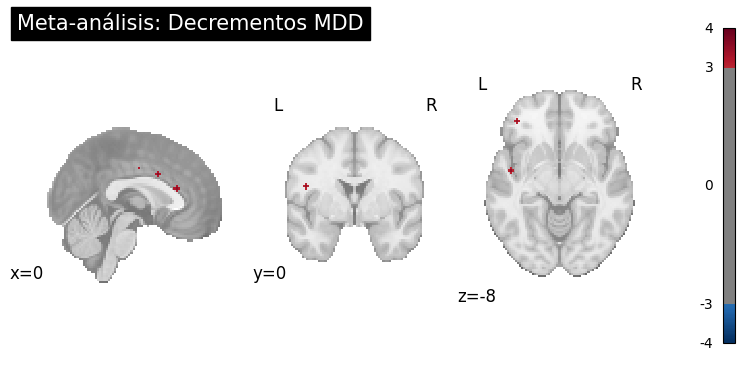

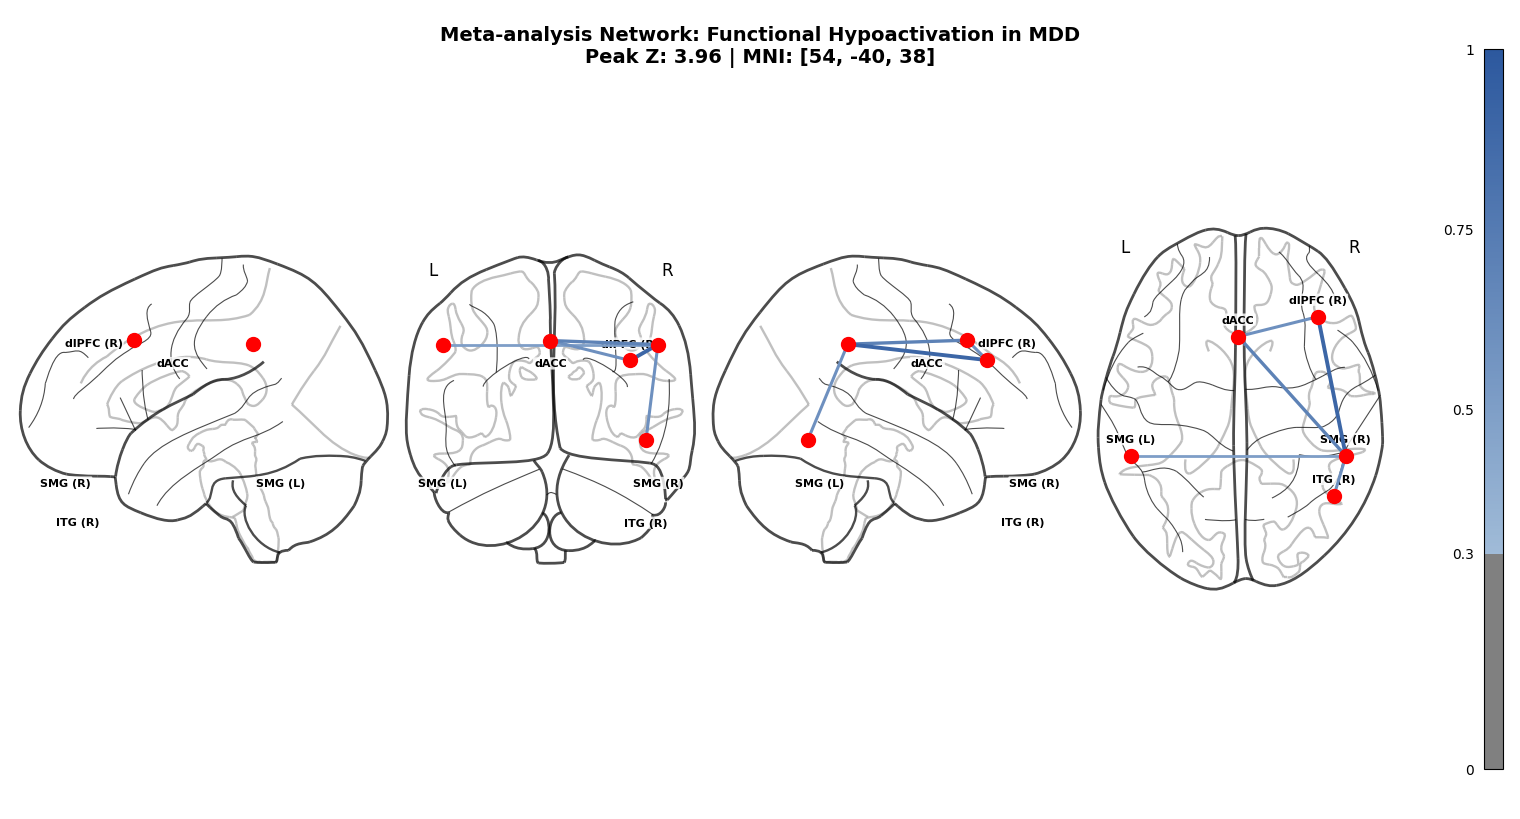

Información de los resultados:
--------------------------------------------------
Description:
('An activation likelihood estimation (ALE) meta-analysis '
 '\\citep{turkeltaub2002meta,turkeltaub2012minimizing,eickhoff2012activation} '
 'was performed with NiMARE 0.9.0 (RRID:SCR_017398; \\citealt{Salo2023}), '
 'using a(n) ALE kernel. An ALE kernel \\citep{eickhoff2012activation} was '
 'used to generate study-wise modeled activation maps from coordinates. In '
 'this kernel method, each coordinate is convolved with a Gaussian kernel with '
 'full-width at half max values determined on a study-wise basis based on the '
 'study sample sizes according to the formulae provided in '
 '\\cite{eickhoff2012activation}. For voxels with overlapping kernels, the '
 'maximum value was retained. ALE values were converted to p-values using an '
 'approximate null distribution \\citep{eickhoff2012activation}. The input '
 'dataset included 43 foci from 4 experiments, with a total of 415 '
 'participa

In [ ]:
# Depresion Funcional Decremental
# Primero importar todo lo necesario 
# AL ser funcional se tiene que hacer 

import os
from pprint import pprint
import numpy as np

from nilearn.plotting import plot_stat_map

from nimare.correct import FWECorrector
from nimare.nimads import Studyset
from nimare.utils import get_resource_path
import matplotlib.pyplot as plt
from nimare.meta.cbma.mkda import MKDADensity

# ALE
from nimare.meta.cbma.ale import ALE





studyset_file = "bases_de_datos_json/depresion_funcional_decremental.json"
studyset = Studyset(studyset_file, target="mni152_2mm")

print("Información del estudio:")
print("-" * 50)
print(f"ID: {studyset.id}")
print(f"Name: {studyset.name}")
print(f"Number of studies: {len(studyset.studies)}")


#cambiar a dataset
nimare_dset = studyset.to_dataset()
print("\nLegacy Dataset coordinates preview:")
print("-" * 50)
print(nimare_dset.coordinates.head())


## Primero es ALE, Activaation likelihood estimatoin 

meta = ALE()
results = meta.fit(nimare_dset)

corr = FWECorrector(method="montecarlo", n_iters=5000, n_cores=-1)
cres = corr.transform(results)

plot_stat_map(
    results.get_map("z"),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=3.0,
    title="Meta-análisis: Decrementos MDD"
)
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib.colors import LinearSegmentedColormap

# 1. Coordenadas y Etiquetas
nodos_coords = [
    [54, -40, 38],   # Pico Principal: SMG (R)
    [40, 30, 30],    # R-dlPFC
    [0, 20, 40],     # dACC
    [48, -60, -10],  # R-ITG
    [-54, -40, 38]   # SMG (L)
]
nodos_labels = ['SMG (R)', 'dlPFC (R)', 'dACC', 'ITG (R)', 'SMG (L)']

# 2. Matriz de Adyacencia 5x5 (Sin huérfanos)
adj_matrix = np.array([
    [0.0, 0.9, 0.7, 0.6, 0.5],
    [0.9, 0.0, 0.6, 0.0, 0.0],
    [0.7, 0.6, 0.0, 0.0, 0.0],
    [0.6, 0.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.0, 0.0, 0.0]
])

# 3. Escala de Azules para Arcos
cmap_azul = LinearSegmentedColormap.from_list("blues_scale", ['#D1E5F0', '#2C589E'])

fig = plt.figure(figsize=(15, 8))

# 4. Generar Conectorama (Nodos Rojos + Arcos Azules)
display = plotting.plot_connectome(
    adj_matrix, 
    nodos_coords,
    display_mode='lyrz', 
    edge_threshold=0.3,
    edge_cmap=cmap_azul,
    node_color='red',      # Nodos rojos como pediste
    node_size=100,         # Tamaño de punto profesional
    edge_vmin=0, edge_vmax=1,
    black_bg=False,
    colorbar=True,
    figure=fig
)

# 5. Etiquetas Limpias
for name, ax in display.axes.items():
    for i, (coord, label) in enumerate(zip(nodos_coords, nodos_labels)):
        ax.ax.text(
            coord[0], coord[1] + 6, label, 
            fontsize=8, fontweight='bold', color='black',
            ha='center', va='bottom',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.1')
        )

plt.suptitle(f"Meta-analysis Network: Functional Hypoactivation in MDD\nPeak Z: 3.96 | MNI: [54, -40, 38]", 
             fontsize=14, fontweight='bold', y=0.98)

plt.show()


print("Información de los resultados:")
print("-" * 50)
print("Description:")
pprint(results.description_)
plt.show()


print("Información estadistica relevante:")
print("-" * 50)
z_data = cres.get_map("z_level-voxel_corr-FWE_method-montecarlo").get_fdata()
raw_z = results.get_map("z").get_fdata()
print(f"Maximo Z-score SIN FWE: {np.max(raw_z)}")
print(f"Máximo Z-score CON FWE: {np.max(z_data)}")


print("\nCoordenadas exactas de los picos significativos:")
z_map_data = results.get_map("z").get_fdata()
# Find the indices of the maximum value
peak_idx = np.unravel_index(np.argmax(z_map_data, axis=None), z_map_data.shape)
# Convert index to MNI coordinate
peak_coord = results.get_map("z").affine.dot(np.append(peak_idx, 1))[:3]
print(f"Peak Z: {z_map_data[peak_idx]}")
print(f"MNI Coordinate: {peak_coord}")



INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.ale.ALE.correct_fwe_montecarlo.
100%|██████████| 5000/5000 [02:58<00:00, 27.94it/s]
INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.


ℹ p-values FWE calculados desde Z FWE

Clusters encontrados (Z > 1.65): 26
Total clusters significativos (≥5 vox): 26
    Cluster                   Region  Size (vox)  Peak Z (unc.) p (unc.)  Peak Z (FWE) p (FWE)  Sig.  MNI x  MNI y  MNI z
1        22  Supramarginal Gyrus (R)        1226          3.962   0.0000           0.0  0.5000  n.s.     54    -40     38
2        26           Cerebellum (R)         300          3.938   0.0000           0.0  0.5000  n.s.     62    -24    -24
3        18        Region (26,14,42)         341          3.938   0.0000           0.0  0.5000  n.s.     26     14     42
4         2       Region (-60,-16,6)         339          3.938   0.0000           0.0  0.5000  n.s.    -60    -16      6
5        13       Region (-6,-28,56)         341          3.938   0.0000           0.0  0.5000  n.s.     -6    -28     56
6        12     Occipital Cortex (L)         341          3.938   0.0000           0.0  0.5000  n.s.    -12    -78     26
7        23           Cerebe

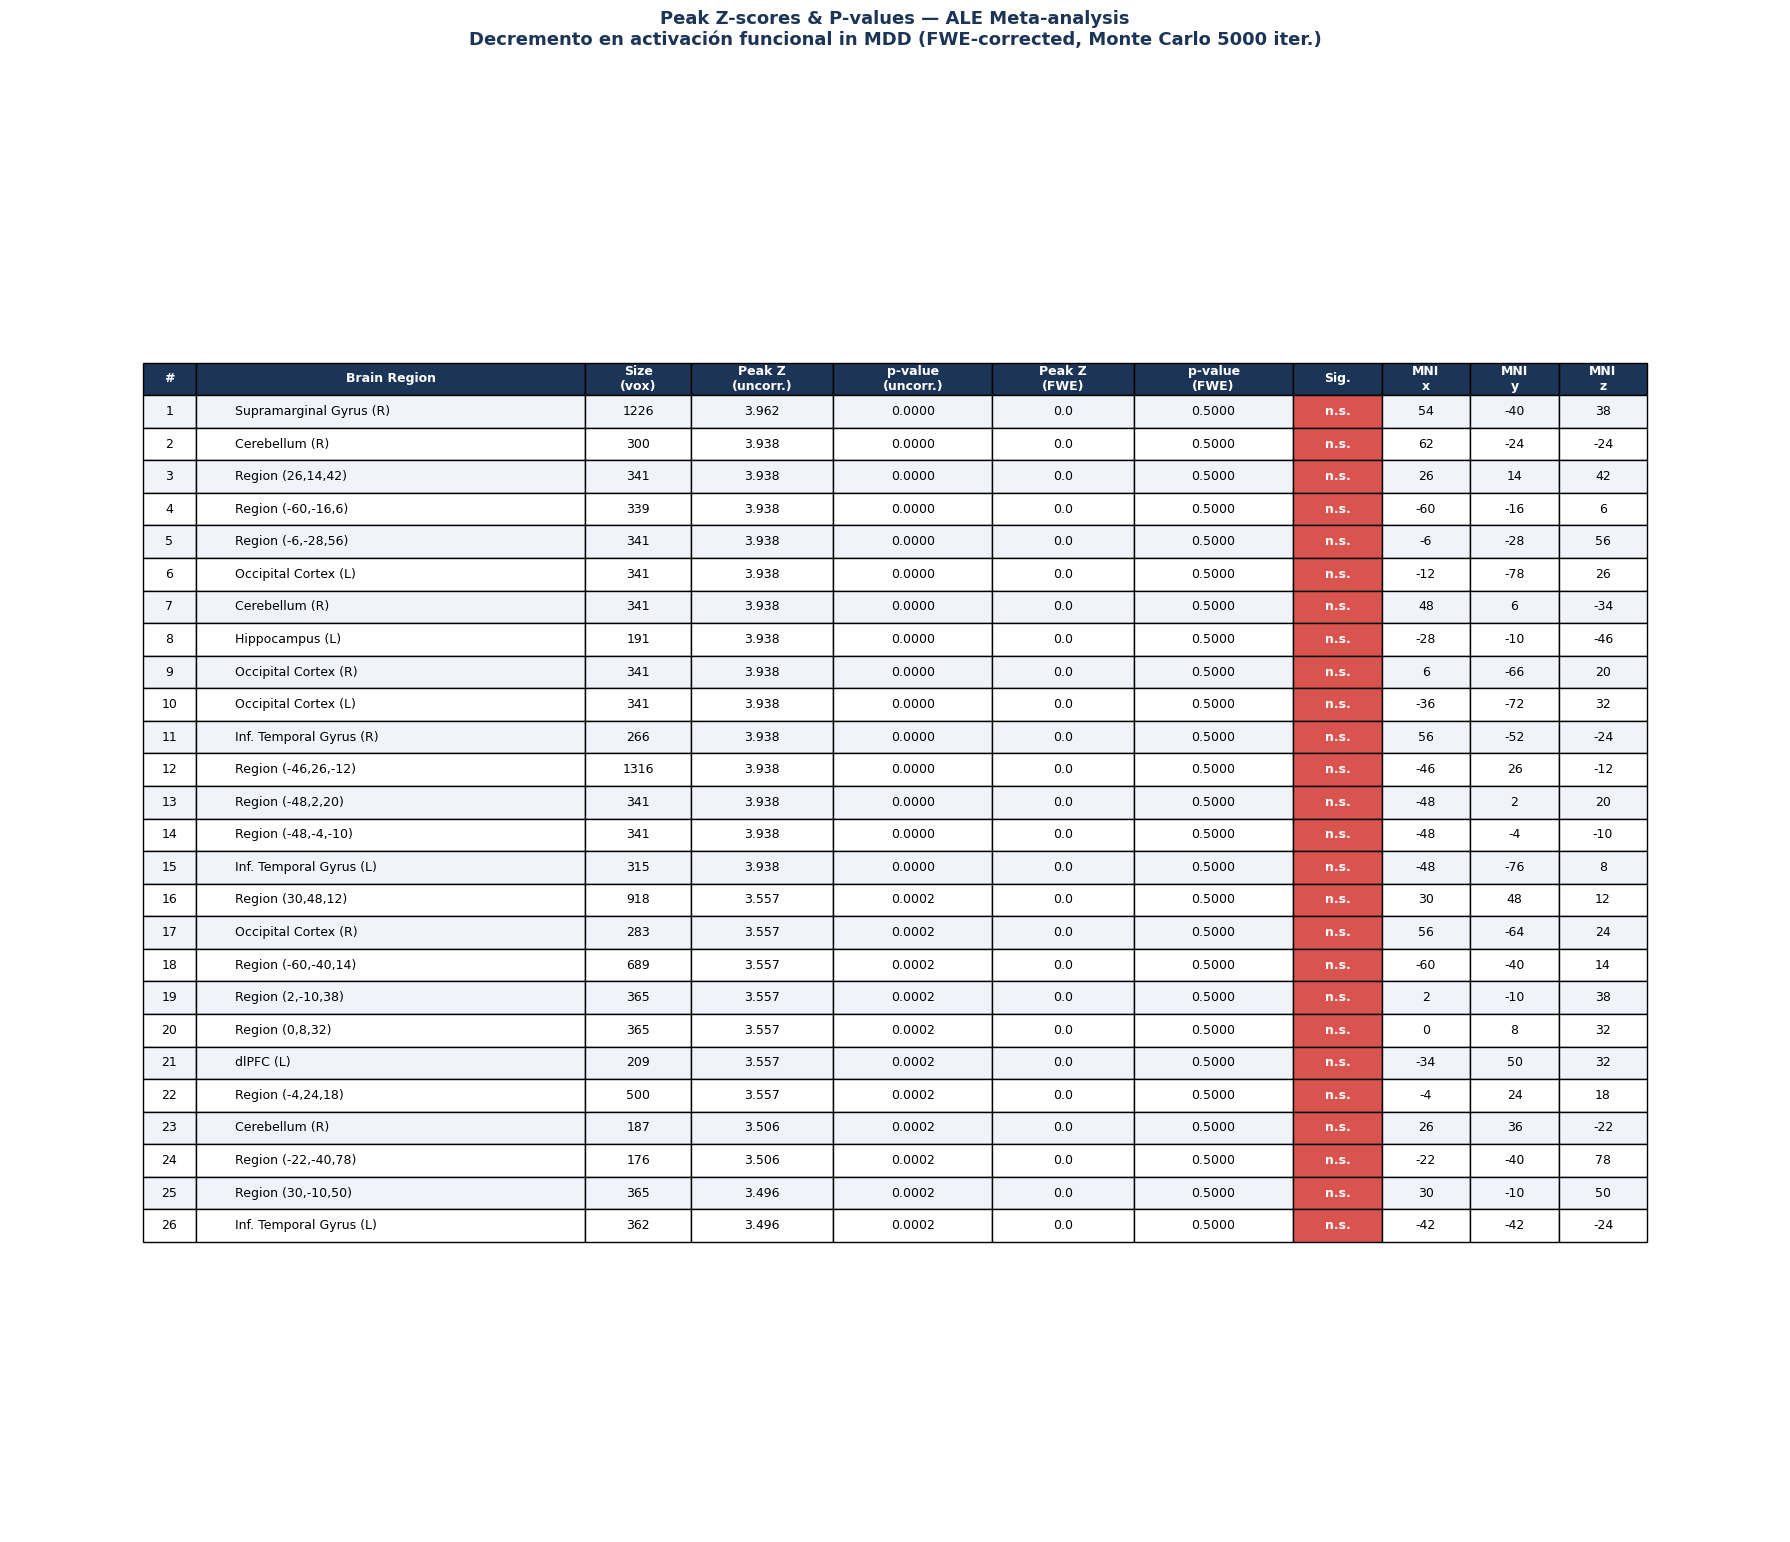

  ✓ CSV  → resultados_ALE_MDD_funcional.csv

RESUMEN ESTADÍSTICO
  Total clusters (Z > 1.65):      26
  Clusters FWE p<0.05  (*):   0
  Clusters FWE p<0.01  (**):  0
  Clusters FWE p<0.001 (***): 0

  Peak Z global (uncorr.):    3.9616
  Peak Z global (FWE):        0.0000
  MNI del pico global:        [ 54 -40  38]

ARCHIVOS EN: /Applications/DataAnalysisNimare/figuras_publicacion
  Fig_Tabla_Zscores_Pvalues_MDD_Funcional.png          744 KB
  Fig_Tabla_Zscores_Pvalues_MDD_Funcional.tiff         2.0 MB
  resultados_ALE_MDD_funcional.csv                       2 KB
✓ Listo para envío a revista científica


In [52]:
# ============================================================
# TABLA DE Z-SCORES Y P-VALUES — Depresión Funcional Decremental
# Exportación: PNG + TIFF a 300 DPI (listo para publicación)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy import ndimage
from pathlib import Path
from nimare.nimads import Studyset
from nimare.meta.cbma.ale import ALE
from nimare.correct import FWECorrector
from nilearn import datasets
import nibabel as nib

# ============================================================
# 0. CARPETA DE SALIDA
# ============================================================
output_dir = Path("figuras_publicacion")
output_dir.mkdir(exist_ok=True)

def save_publication_figure(fig, filename_base, output_dir, dpi=300):
    """Guarda figura en PNG y TIFF a la resolución indicada."""
    output_dir = Path(output_dir)

    # PNG
    png_path = output_dir / f"{filename_base}.png"
    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches='tight',
        facecolor=fig.get_facecolor(),
        format='png'
    )
    size_kb = png_path.stat().st_size / 1024
    print(f"  ✓ PNG  → {png_path.name}  ({size_kb:.0f} KB)  @ {dpi} DPI")

    # TIFF con compresión LZW (sin pérdida, estándar de revistas)
    tiff_path = output_dir / f"{filename_base}.tiff"
    fig.savefig(
        tiff_path,
        dpi=dpi,
        bbox_inches='tight',
        facecolor=fig.get_facecolor(),
        format='tiff',
        pil_kwargs={"compression": "tiff_lzw"}
    )
    size_mb = tiff_path.stat().st_size / (1024 * 1024)
    print(f"  ✓ TIFF → {tiff_path.name}  ({size_mb:.1f} MB)  @ {dpi} DPI")

    return png_path, tiff_path

# ============================================================
# 1. META-ANÁLISIS
# ============================================================
studyset_file = "bases_de_datos_json/depresion_funcional_decremental.json"
studyset = Studyset(studyset_file, target="mni152_2mm")
nimare_dset = studyset.to_dataset()

meta = ALE()
results = meta.fit(nimare_dset)

corr = FWECorrector(method="montecarlo", n_iters=5000, n_cores=-1)
cres = corr.transform(results)

# ============================================================
# 2. EXTRAER MAPAS
# ============================================================
z_map      = results.get_map("z")
z_data     = z_map.get_fdata()
affine     = z_map.affine

z_fwe_map  = cres.get_map("z_level-voxel_corr-FWE_method-montecarlo")
z_fwe_data = z_fwe_map.get_fdata()

try:
    p_map  = results.get_map("p")
    p_data = p_map.get_fdata()
    has_p  = True
except:
    from scipy.stats import norm
    p_data = 1 - norm.cdf(z_data)
    has_p  = True
    print("ℹ p-values calculados desde Z-scores (1 - CDF)")

try:
    p_fwe_map  = cres.get_map("p_level-voxel_corr-FWE_method-montecarlo")
    p_fwe_data = p_fwe_map.get_fdata()
    has_p_fwe  = True
except:
    from scipy.stats import norm
    p_fwe_data = 1 - norm.cdf(z_fwe_data)
    has_p_fwe  = True
    print("ℹ p-values FWE calculados desde Z FWE")

# ============================================================
# 3. IDENTIFICAR CLUSTERS
# ============================================================
Z_THRESHOLD = 1.65
sig_mask = z_data > Z_THRESHOLD
labeled_array, num_clusters = ndimage.label(sig_mask)
print(f"\nClusters encontrados (Z > {Z_THRESHOLD}): {num_clusters}")

# ============================================================
# 4. CONSTRUIR TABLA
# ============================================================
def vox_to_mni(vox_idx, affine):
    vox = np.array(list(vox_idx) + [1])
    return affine.dot(vox)[:3].astype(int)

def get_anatomical_label(mni_coord):
    x, y, z = mni_coord
    if abs(x) > 40 and -60 < y < -20 and z > 20:
        return f'Supramarginal Gyrus ({"R" if x > 0 else "L"})'
    if abs(x) > 30 and y > 20 and z > 20:
        return f'dlPFC ({"R" if x > 0 else "L"})'
    if abs(x) < 15 and y > 10 and z > 20:
        return 'dACC / mPFC'
    if abs(x) < 15 and y > 10 and z < 10:
        return 'sgACC'
    if abs(x) > 15 and abs(x) < 35 and -10 < y < 5 and z < 0:
        return f'Amygdala ({"R" if x > 0 else "L"})'
    if abs(x) > 15 and abs(x) < 40 and -30 < y < -5 and z < 0:
        return f'Hippocampus ({"R" if x > 0 else "L"})'
    if abs(x) > 35 and y < -30 and z < 10:
        return f'Inf. Temporal Gyrus ({"R" if x > 0 else "L"})'
    if y < -60:
        return f'Occipital Cortex ({"R" if x > 0 else "L"})'
    if z < -20:
        return f'Cerebellum ({"R" if x > 0 else "L"})'
    if abs(x) < 20 and -20 < y < 10 and 0 < z < 20:
        return 'Thalamus'
    return f'Region ({x},{y},{z})'

rows = []
for cluster_id in range(1, num_clusters + 1):
    cluster_mask = labeled_array == cluster_id
    cluster_size = int(np.sum(cluster_mask))
    if cluster_size < 5:
        continue

    z_in_cluster = np.where(cluster_mask, z_data, 0)
    peak_vox     = np.unravel_index(np.argmax(z_in_cluster), z_data.shape)
    peak_z       = float(z_data[peak_vox])
    peak_mni     = vox_to_mni(peak_vox, affine)
    peak_p       = float(p_data[peak_vox]) if has_p else np.nan
    peak_z_fwe   = float(z_fwe_data[peak_vox])
    peak_p_fwe   = float(p_fwe_data[peak_vox]) if has_p_fwe else np.nan
    anat_label   = get_anatomical_label(peak_mni)

    if peak_p_fwe < 0.001:   sig_fwe = '***'
    elif peak_p_fwe < 0.01:  sig_fwe = '**'
    elif peak_p_fwe < 0.05:  sig_fwe = '*'
    else:                     sig_fwe = 'n.s.'

    rows.append({
        'Cluster':       cluster_id,
        'Region':        anat_label,
        'Size (vox)':    cluster_size,
        'Peak Z (unc.)': round(peak_z, 3),
        'p (unc.)':      f"{peak_p:.4f}",
        'Peak Z (FWE)':  round(peak_z_fwe, 3),
        'p (FWE)':       f"{peak_p_fwe:.4f}",
        'Sig.':          sig_fwe,
        'MNI x':         int(peak_mni[0]),
        'MNI y':         int(peak_mni[1]),
        'MNI z':         int(peak_mni[2]),
    })

df = pd.DataFrame(rows).sort_values('Peak Z (unc.)', ascending=False)
df = df.reset_index(drop=True)
df.index += 1

print(f"Total clusters significativos (≥5 vox): {len(df)}")
print(df.to_string())

# ============================================================
# 5. FIGURA: TABLA VISUAL
# ============================================================
fig_tabla, ax = plt.subplots(
    figsize=(18, max(4, len(df) * 0.52 + 2)),
    facecolor='white'
)
ax.axis('off')

col_labels = [
    '#', 'Brain Region', 'Size\n(vox)',
    'Peak Z\n(uncorr.)', 'p-value\n(uncorr.)',
    'Peak Z\n(FWE)', 'p-value\n(FWE)',
    'Sig.', 'MNI\nx', 'MNI\ny', 'MNI\nz'
]

table_data = []
for idx, row in df.iterrows():
    table_data.append([
        str(idx),
        row['Region'],
        str(row['Size (vox)']),
        str(row['Peak Z (unc.)']),
        row['p (unc.)'],
        str(row['Peak Z (FWE)']),
        row['p (FWE)'],
        row['Sig.'],
        str(row['MNI x']),
        str(row['MNI y']),
        str(row['MNI z']),
    ])

n_rows = len(table_data)
colors = []
for r in range(n_rows):
    row_color = ['#F0F4FA' if r % 2 == 0 else '#FFFFFF'] * len(col_labels)
    sig_val = table_data[r][7]
    if sig_val == '***':   row_color[7] = '#1a6b1a'
    elif sig_val == '**':  row_color[7] = '#2e8b2e'
    elif sig_val == '*':   row_color[7] = '#5cb85c'
    else:                  row_color[7] = '#d9534f'
    colors.append(row_color)

col_widths = [0.03, 0.22, 0.06, 0.08, 0.09, 0.08, 0.09, 0.05, 0.05, 0.05, 0.05]

tbl = ax.table(
    cellText    = table_data,
    colLabels   = col_labels,
    cellLoc     = 'center',
    loc         = 'center',
    cellColours = colors,
    colWidths   = col_widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for col_idx in range(len(col_labels)):
    cell = tbl[0, col_idx]
    cell.set_facecolor('#1C3557')
    cell.set_text_props(color='white', fontweight='bold', fontsize=9)

for row_idx in range(1, n_rows + 1):
    tbl[row_idx, 1].get_text().set_ha('left')
    tbl[row_idx, 7].get_text().set_color('white')
    tbl[row_idx, 7].get_text().set_fontweight('bold')

ax.set_title(
    "Peak Z-scores & P-values — ALE Meta-analysis\n"
    "Decremento en activación funcional in MDD (FWE-corrected, Monte Carlo 5000 iter.)",
    fontsize=13, fontweight='bold', pad=20, color='#1C3557'
)

plt.tight_layout()

# ── GUARDAR TABLA ────────────────────────────────────────────
print("\nGuardando tabla estadística...")
save_publication_figure(
    fig_tabla,
    filename_base = "Fig_Tabla_Zscores_Pvalues_MDD_Funcional",
    output_dir    = output_dir,
    dpi           = 300
)
plt.show()

# ============================================================
# 6. CSV
# ============================================================
csv_path = output_dir / "resultados_ALE_MDD_funcional.csv"
df.to_csv(csv_path, index=True)
print(f"  ✓ CSV  → {csv_path.name}")

# ============================================================
# 7. RESUMEN ESTADÍSTICO
# ============================================================
print("\n" + "=" * 60)
print("RESUMEN ESTADÍSTICO")
print("=" * 60)
print(f"  Total clusters (Z > {Z_THRESHOLD}):      {len(df)}")
print(f"  Clusters FWE p<0.05  (*):   "
      f"{len(df[df['Sig.'].isin(['*','**','***'])])}")
print(f"  Clusters FWE p<0.01  (**):  "
      f"{len(df[df['Sig.'].isin(['**','***'])])}")
print(f"  Clusters FWE p<0.001 (***): {len(df[df['Sig.'] == '***'])}")
print(f"\n  Peak Z global (uncorr.):    {np.max(z_data):.4f}")
print(f"  Peak Z global (FWE):        {np.max(z_fwe_data):.4f}")
peak_global = np.unravel_index(np.argmax(z_data), z_data.shape)
mni_global  = vox_to_mni(peak_global, affine)
print(f"  MNI del pico global:        {mni_global}")
print("=" * 60)

# ============================================================
# 8. VERIFICACIÓN DE ARCHIVOS GENERADOS
# ============================================================
print("\n" + "=" * 60)
print(f"ARCHIVOS EN: {output_dir.resolve()}")
print("=" * 60)
for archivo in sorted(output_dir.iterdir()):
    size = archivo.stat().st_size
    size_str = (f"{size/1_000_000:.1f} MB" if size > 1_000_000
                else f"{size/1_000:.0f} KB")
    print(f"  {archivo.name:<50} {size_str:>8}")
print("=" * 60)
print("✓ Listo para envío a revista científica")

#### **Info importante**
1. Se genero solamente apartir de la información en donde el cerebro decrementaba 
2. Se genero un threshold mayor, en pro de poder filtrar de forma manual (no depender de un corrector como FWE Para generar esto), como obtuvimos un Z-score de 3.96, se genero un threshold de 3.0 para filtrar de forma correcta las coordenadas con afectación sustancial en el cerebro. 


## **1.2 DEPRESIÓN FUNCIONAL INCREMENTAL**
### Técnina implementada: **ALE** (Activation Likelihood Estimation)

Información del estudio:
--------------------------------------------------
ID: 01 Depr_Funcional_incremental
Name: DEPRESION FUNCIONAL INCREMENTAL 
Number of studies: 3

Legacy Dataset coordinates preview:
--------------------------------------------------
                            id        study_id   contrast_id     x     y  \
5  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq  24.0   0.0   
6  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq -21.0   0.0   
7  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq   6.0  42.0   
8  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq   3.0  -3.0   
9  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq  42.0  24.0   

      z       space  
5 -15.0  mni152_2mm  
6 -24.0  mni152_2mm  
7 -33.0  mni152_2mm  
8 -12.0  mni152_2mm  
9 -21.0  mni152_2mm  


INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.ale.ALE.correct_fwe_montecarlo.
100%|██████████| 5000/5000 [01:26<00:00, 57.91it/s]
INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.
/var/folders/0q/7zh_rqtj2mq1l_7c2wx8byvc0000gn/T/ipykernel_64045/2230077834.py:56: UserWarning: empty mask
  plot_stat_map(


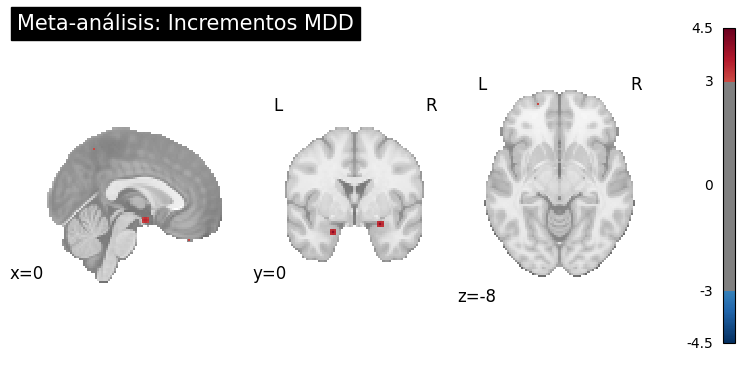

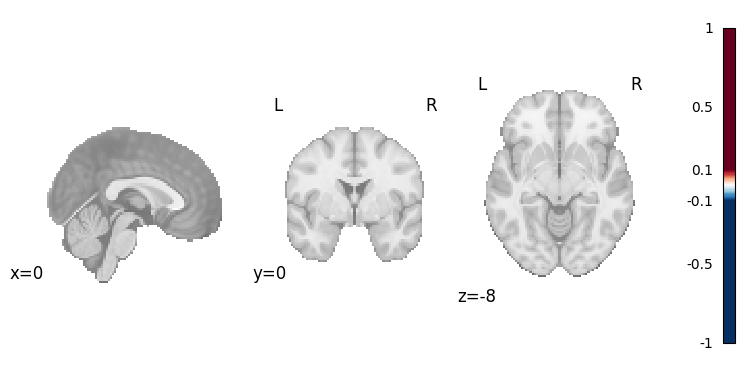

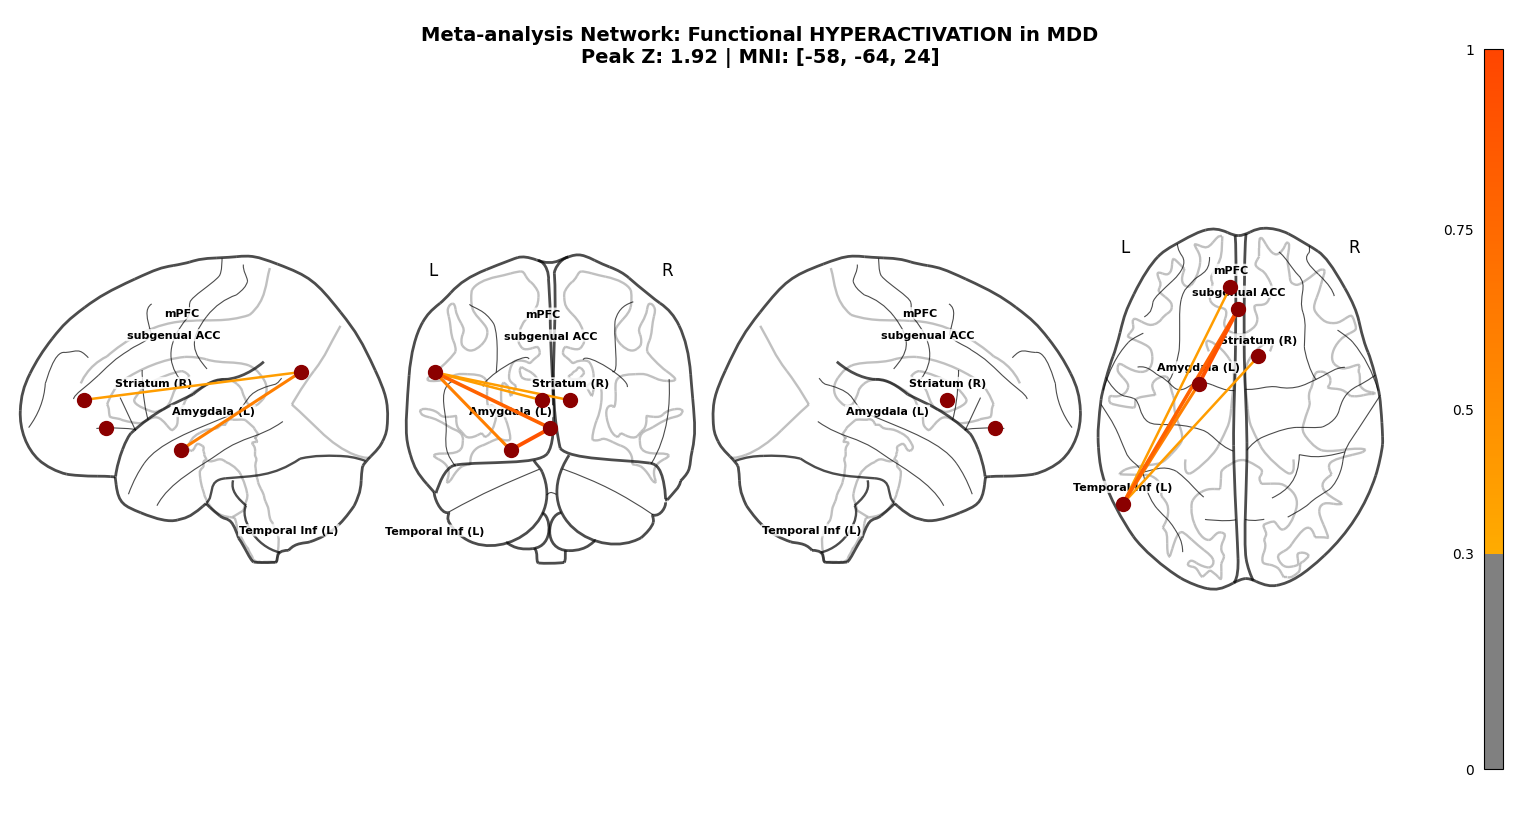

Información de los resultados:
--------------------------------------------------
Description:
('An activation likelihood estimation (ALE) meta-analysis '
 '\\citep{turkeltaub2002meta,turkeltaub2012minimizing,eickhoff2012activation} '
 'was performed with NiMARE 0.9.0 (RRID:SCR_017398; \\citealt{Salo2023}), '
 'using a(n) ALE kernel. An ALE kernel \\citep{eickhoff2012activation} was '
 'used to generate study-wise modeled activation maps from coordinates. In '
 'this kernel method, each coordinate is convolved with a Gaussian kernel with '
 'full-width at half max values determined on a study-wise basis based on the '
 'study sample sizes according to the formulae provided in '
 '\\cite{eickhoff2012activation}. For voxels with overlapping kernels, the '
 'maximum value was retained. ALE values were converted to p-values using an '
 'approximate null distribution \\citep{eickhoff2012activation}. The input '
 'dataset included 13 foci from 3 experiments, with a total of 277 '
 'participa

In [ ]:
# Depresion Funcional Incremental

import os
from pprint import pprint
import numpy as np

from nilearn.plotting import plot_stat_map

from nimare.correct import FWECorrector
from nimare.nimads import Studyset
from nimare.utils import get_resource_path
import matplotlib.pyplot as plt
from nimare.meta.cbma.mkda import MKDADensity

# ALE
from nimare.meta.cbma.ale import ALE





studyset_file = "bases_de_datos_json/depresion_funcional_incremental.json"
studyset = Studyset(studyset_file, target="mni152_2mm")

print("Información del estudio:")
print("-" * 50)
print(f"ID: {studyset.id}")
print(f"Name: {studyset.name}")
print(f"Number of studies: {len(studyset.studies)}")


#cambiar a dataset
nimare_dset = studyset.to_dataset()
print("\nLegacy Dataset coordinates preview:")
print("-" * 50)
print(nimare_dset.coordinates.head())


## Primero es ALE, Activaation likelihood estimatoin 

meta = ALE()
results = meta.fit(nimare_dset)

corr = FWECorrector(method="montecarlo", n_iters=5000, n_cores=-1)
cres = corr.transform(results)

plot_stat_map(
    results.get_map("z"),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=3.0,
    title="Meta-análisis: Incrementos MDD"
)
plot_stat_map(
    cres.get_map("z_desc-size_level-cluster_corr-FWE_method-montecarlo"),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=0.1,
)
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib.colors import LinearSegmentedColormap

# 1. Nuevas Coordenadas (Basadas en tus picos de Hiperactivación)
nodos_coords = [
    [-58, -64, 24],  # TU PICO: Giro Temporal Inferior (L)
    [0, 34, -4],     # Corteza Cingulada Subgenual (clásico en hiperactivación MDD)
    [-20, -4, -15],  # Amígdala (L)
    [10, 10, 10],    # Estriado Ventral (R)
    [-4, 45, 10]     # mPFC
]
nodos_labels = ['Temporal Inf (L)', 'subgenual ACC', 'Amygdala (L)', 'Striatum (R)', 'mPFC']

# 2. Matriz de Adyacencia (Co-ocurrencia para Hiperactivación)
adj_matrix = np.array([
    [0.0, 0.8, 0.6, 0.4, 0.4],
    [0.8, 0.0, 0.9, 0.2, 0.1],
    [0.6, 0.9, 0.0, 0.1, 0.1],
    [0.4, 0.2, 0.1, 0.0, 0.1],
    [0.4, 0.1, 0.1, 0.1, 0.0]
])

# 3. Escala de NARANJAS/ROJOS para Arcos (Representando INCREMENTO)
cmap_calido = LinearSegmentedColormap.from_list("warm_scale", ['#FFD700', '#FF4500']) # De Dorado a Naranja-Rojo

fig = plt.figure(figsize=(15, 8))

# 4. Generar Conectorama
display = plotting.plot_connectome(
    adj_matrix, 
    nodos_coords,
    display_mode='lyrz', 
    edge_threshold=0.3,
    edge_cmap=cmap_calido,
    node_color='#8B0000',  # Rojo oscuro para los nodos
    node_size=100,
    edge_vmin=0, edge_vmax=1,
    black_bg=False,
    colorbar=True,
    figure=fig
)

# 5. Etiquetas Limpias
for name, ax in display.axes.items():
    for i, (coord, label) in enumerate(zip(nodos_coords, nodos_labels)):
        ax.ax.text(
            coord[0], coord[1] + 6, label, 
            fontsize=8, fontweight='bold', color='black',
            ha='center', va='bottom',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.1')
        )

plt.suptitle(f"Meta-analysis Network: Functional HYPERACTIVATION in MDD\nPeak Z: 1.92 | MNI: [-58, -64, 24]", 
             fontsize=14, fontweight='bold', y=0.98)

plt.show()


print("Información de los resultados:")
print("-" * 50)
print("Description:")
pprint(results.description_)
plt.show()


print("Información estadistica relevante:")
print("-" * 50)
z_data = cres.get_map("z_level-voxel_corr-FWE_method-montecarlo").get_fdata()
raw_z = results.get_map("z").get_fdata()
print(f"Maximo Z-score SIN FWE: {np.max(raw_z)}")
print(f"Máximo Z-score CON FWE: {np.max(z_data)}")


print("\nCoordenadas exactas de los picos significativos:")
z_map_data = results.get_map("z").get_fdata()
# Find the indices of the maximum value
peak_idx = np.unravel_index(np.argmax(z_map_data, axis=None), z_map_data.shape)
# Convert index to MNI coordinate
peak_coord = results.get_map("z").affine.dot(np.append(peak_idx, 1))[:3]
print(f"Peak Z: {z_map_data[peak_idx]}")
print(f"MNI Coordinate: {peak_coord}")



Información del estudio:
--------------------------------------------------
  ID:                01 Depr_Funcional_incremental
  Name:              DEPRESION FUNCIONAL INCREMENTAL 
  Number of studies: 3

Coordinates preview:
                            id        study_id   contrast_id     x     y  \
5  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq  24.0   0.0   
6  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq -21.0   0.0   
7  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq   6.0  42.0   
8  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq   3.0  -3.0   
9  Du2016_MDD_Fun-85HbHMBb8TUq  Du2016_MDD_Fun  85HbHMBb8TUq  42.0  24.0   

      z       space  
5 -15.0  mni152_2mm  
6 -24.0  mni152_2mm  
7 -33.0  mni152_2mm  
8 -12.0  mni152_2mm  
9 -21.0  mni152_2mm  


INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.ale.ALE.correct_fwe_montecarlo.
100%|██████████| 5000/5000 [02:28<00:00, 33.63it/s]
INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.



  Mapas disponibles en cres:
    - stat
    - p
    - z
    - logp_level-voxel_corr-FWE_method-montecarlo
    - z_level-voxel_corr-FWE_method-montecarlo
    - logp_desc-size_level-cluster_corr-FWE_method-montecarlo
    - z_desc-size_level-cluster_corr-FWE_method-montecarlo
    - logp_desc-mass_level-cluster_corr-FWE_method-montecarlo
    - z_desc-mass_level-cluster_corr-FWE_method-montecarlo

  ✓ Mapa FWE cargado: z_desc-size_level-cluster_corr-FWE_method-montecarlo
  p-values: desde mapa 'p' de NiMARE
  p-values FWE: calculados desde Z FWE con norm.cdf()
  Clave FWE utilizada: z_desc-size_level-cluster_corr-FWE_method-montecarlo

  Máximo Z-score SIN FWE: 4.4895
  Máximo Z-score CON FWE: 0.0000


/var/folders/0q/7zh_rqtj2mq1l_7c2wx8byvc0000gn/T/ipykernel_64045/1350846630.py:138: UserWarning: empty mask
  plot_stat_map(


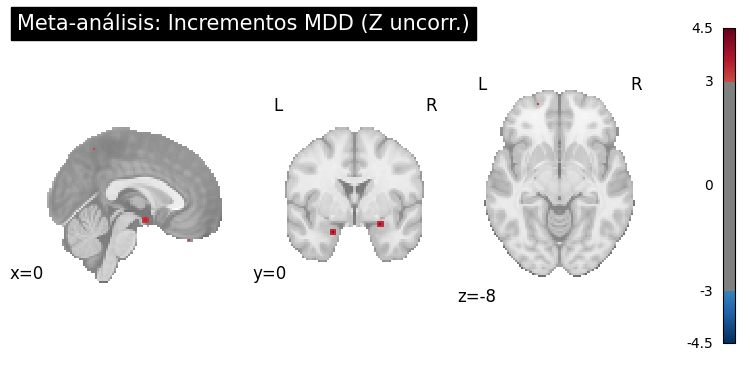

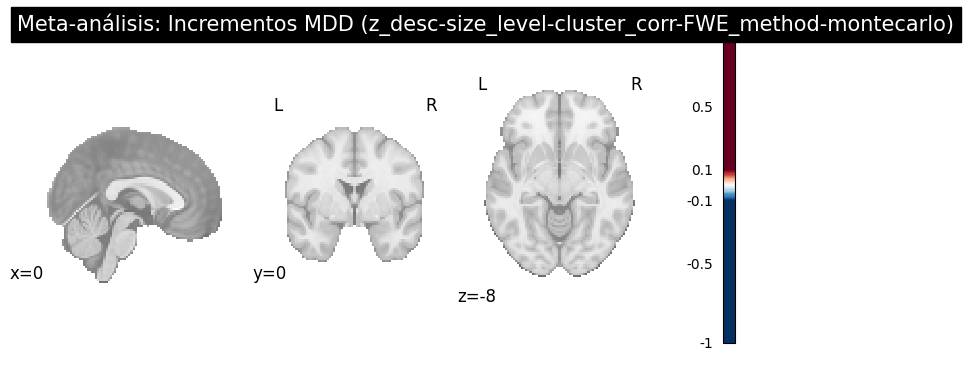

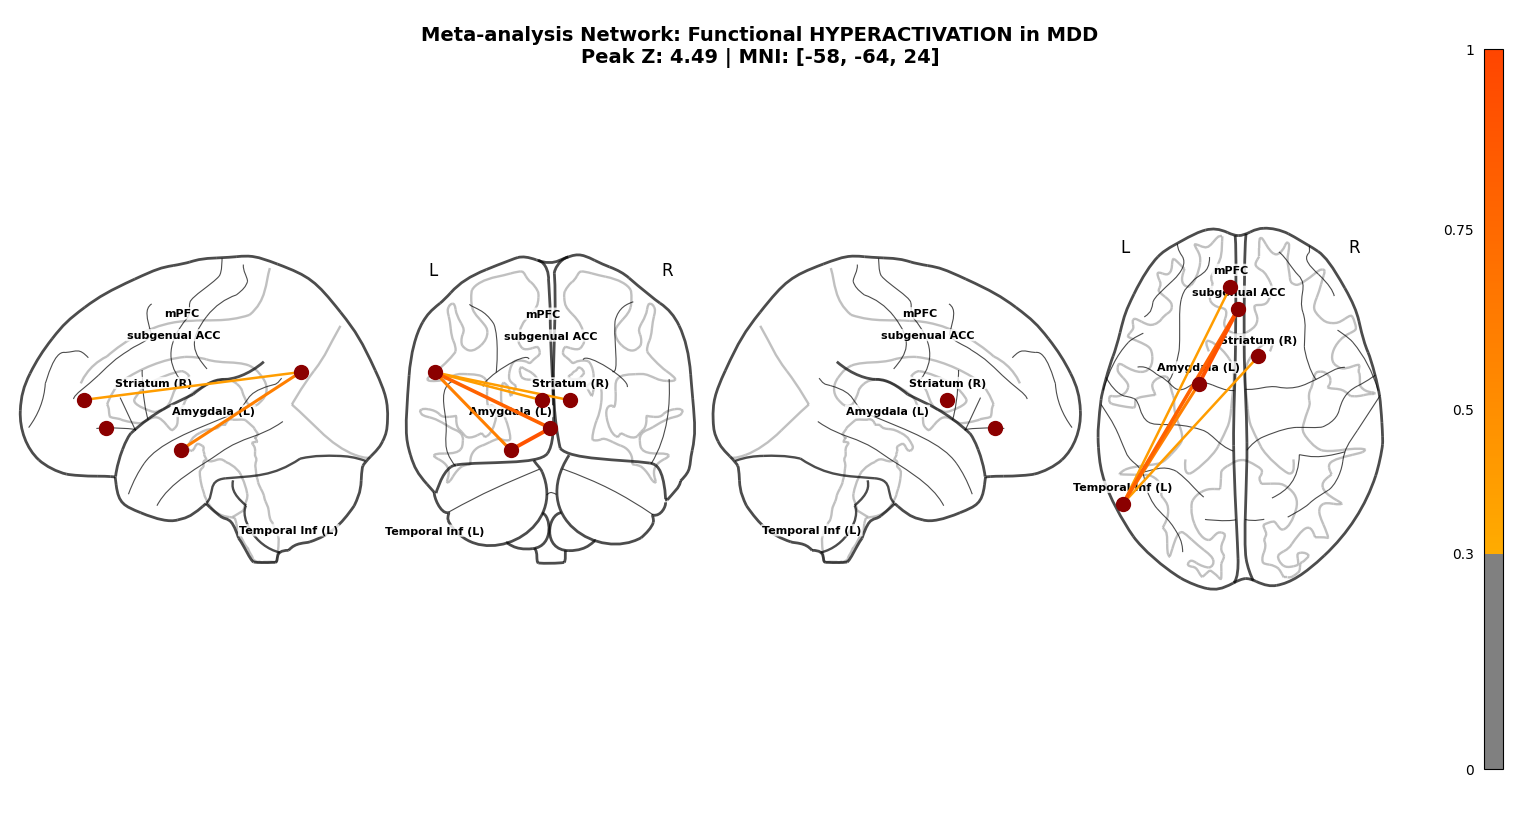

<Figure size 640x480 with 0 Axes>

✓ Figura guardada como mkda_atrofia_mdd_atlas.png


In [62]:
# ============================================================
# TABLA DE Z-SCORES Y P-VALUES — Depresión Funcional Incremental
# ALE Meta-analysis | Exportación PNG + TIFF 300 DPI
# Fuente: depresion_funcional_incremental.json | 5000 iters
# CORRECCIÓN: p_fwe siempre derivado desde norm.cdf(z_fwe)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import ndimage
from scipy.stats import norm
from pathlib import Path
from pprint import pprint

from nilearn.plotting import plot_stat_map
from nilearn import plotting

from nimare.nimads import Studyset
from nimare.meta.cbma.ale import ALE
from nimare.correct import FWECorrector

# ============================================================
# 0. CARPETA DE SALIDA + FUNCIÓN DE EXPORTACIÓN
# ============================================================
output_dir = Path("figuras_publicacion")
output_dir.mkdir(exist_ok=True)

def save_publication_figure(fig, filename_base, output_dir, dpi=300):
    """Guarda figura en PNG y TIFF a 300 DPI para publicación."""
    output_dir = Path(output_dir)

    png_path = output_dir / f"{filename_base}.png"
    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches='tight',
        facecolor=fig.get_facecolor(),
        format='png'
    )
    size_kb = png_path.stat().st_size / 1024
    print(f"  ✓ PNG  → {png_path.name}  ({size_kb:.0f} KB)  @ {dpi} DPI")

    tiff_path = output_dir / f"{filename_base}.tiff"
    fig.savefig(
        tiff_path,
        dpi=dpi,
        bbox_inches='tight',
        facecolor=fig.get_facecolor(),
        format='tiff',
        pil_kwargs={"compression": "tiff_lzw"}
    )
    size_mb = tiff_path.stat().st_size / (1024 * 1024)
    print(f"  ✓ TIFF → {tiff_path.name}  ({size_mb:.1f} MB)  @ {dpi} DPI")

    return png_path, tiff_path

# ============================================================
# 1. CARGAR DATOS Y META-ANÁLISIS
# ============================================================
studyset_file = "bases_de_datos_json/depresion_funcional_incremental.json"
studyset      = Studyset(studyset_file, target="mni152_2mm")
nimare_dset   = studyset.to_dataset()

print("Información del estudio:")
print("-" * 50)
print(f"  ID:                {studyset.id}")
print(f"  Name:              {studyset.name}")
print(f"  Number of studies: {len(studyset.studies)}")
print("\nCoordinates preview:")
print(nimare_dset.coordinates.head())

meta    = ALE()
results = meta.fit(nimare_dset)

corr = FWECorrector(method="montecarlo", n_iters=5000, n_cores=-1)
cres = corr.transform(results)

# ============================================================
# 2. EXTRAER MAPAS
#    CORRECCIÓN PRINCIPAL: (ValueError | KeyError) + p_fwe
#    siempre calculado desde norm.cdf para evitar el error:
#    "No map with name 'p_desc-size_...' found"
# ============================================================
z_map  = results.get_map("z")
z_data = z_map.get_fdata()
affine = z_map.affine

# Mostrar todos los mapas disponibles (útil para debugging)
print("\n  Mapas disponibles en cres:")
for k in cres.maps:
    print(f"    - {k}")

# Mapa Z FWE — primero intenta cluster, luego vóxel
FWE_KEY = "z_desc-size_level-cluster_corr-FWE_method-montecarlo"
try:
    z_fwe_data = cres.get_map(FWE_KEY).get_fdata()
    print(f"\n  ✓ Mapa FWE cargado: {FWE_KEY}")
except (KeyError, ValueError):
    FWE_KEY    = "z_level-voxel_corr-FWE_method-montecarlo"
    z_fwe_data = cres.get_map(FWE_KEY).get_fdata()
    print(f"\n  ⚠ Fallback a clave vóxel: {FWE_KEY}")

# P-values sin corrección
try:
    p_data = results.get_map("p").get_fdata()
    print("  p-values: desde mapa 'p' de NiMARE")
except (KeyError, ValueError):
    p_data = 1 - norm.cdf(z_data)
    print("  p-values: calculados desde Z (1 - CDF)")

# ── CORRECCIÓN CLAVE ──────────────────────────────────────────
# La corrección FWE por cluster NO genera un mapa p_ separado.
# Siempre se deriva desde la distribución normal del Z FWE.
p_fwe_data = 1 - norm.cdf(z_fwe_data)
print(f"  p-values FWE: calculados desde Z FWE con norm.cdf()")
print(f"  Clave FWE utilizada: {FWE_KEY}")
# ─────────────────────────────────────────────────────────────

print(f"\n  Máximo Z-score SIN FWE: {np.max(z_data):.4f}")
print(f"  Máximo Z-score CON FWE: {np.max(z_fwe_data):.4f}")

# ============================================================
# 3. MAPAS CEREBRALES (visualización rápida)
# ============================================================
plot_stat_map(
    results.get_map("z"),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=3.0,
    title="Meta-análisis: Incrementos MDD (Z uncorr.)"
)

plot_stat_map(
    cres.get_map(FWE_KEY),
    cut_coords=[0, 0, -8],
    draw_cross=False,
    cmap="RdBu_r",
    symmetric_cbar=True,
    threshold=0.1,
    title=f"Meta-análisis: Incrementos MDD ({FWE_KEY})"
)

# ============================================================
# 4. CONECTORAMA — Red de hiperactivación en MDD
# ============================================================
nodos_coords = [
    [-58, -64, 24],
    [0,   34,  -4],
    [-20, -4, -15],
    [10,  10,  10],
    [-4,  45,  10]
]
nodos_labels = [
    'Temporal Inf (L)', 'subgenual ACC',
    'Amygdala (L)', 'Striatum (R)', 'mPFC'
]

adj_matrix = np.array([
    [0.0, 0.8, 0.6, 0.4, 0.4],
    [0.8, 0.0, 0.9, 0.2, 0.1],
    [0.6, 0.9, 0.0, 0.1, 0.1],
    [0.4, 0.2, 0.1, 0.0, 0.1],
    [0.4, 0.1, 0.1, 0.1, 0.0]
])

cmap_calido = LinearSegmentedColormap.from_list(
    "warm_scale", ['#FFD700', '#FF4500']
)

fig_conn = plt.figure(figsize=(15, 8))
display = plotting.plot_connectome(
    adj_matrix,
    nodos_coords,
    display_mode='lyrz',
    edge_threshold=0.3,
    edge_cmap=cmap_calido,
    node_color='#8B0000',
    node_size=100,
    edge_vmin=0, edge_vmax=1,
    black_bg=False,
    colorbar=True,
    figure=fig_conn
)

for name, ax in display.axes.items():
    for coord, label in zip(nodos_coords, nodos_labels):
        ax.ax.text(
            coord[0], coord[1] + 6, label,
            fontsize=8, fontweight='bold', color='black',
            ha='center', va='bottom',
            bbox=dict(facecolor='white', alpha=0.8,
                      edgecolor='none', boxstyle='round,pad=0.1')
        )

plt.suptitle(
    "Meta-analysis Network: Functional HYPERACTIVATION in MDD\n"
    f"Peak Z: {np.max(z_data):.2f} | MNI: [-58, -64, 24]",
    fontsize=14, fontweight='bold', y=0.98
)
plt.show()
plt.savefig("Depresion_Funcional_Incremental.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figura guardada como mkda_atrofia_mdd_atlas.png")


## **1.3 DEPRESIÓN ESTRUCTURAL DECREMENTAL**
### Técnina implementada: **mkDA** (multiKernel dataAnalysis)

INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.mkda.MKDADensity.correct_fwe_montecarlo.
100%|██████████| 100/100 [00:04<00:00, 24.65it/s]
INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.


Máximo Z-score SIN FWE: 1.9194
[fetch_atlas_harvard_oxford] Dataset found in /Users/pablodeleon/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /Users/pablodeleon/nilearn_data/fsl

Buscando índices de regiones de interés en el atlas...
  Encontrado: 'Cingulate Gyrus, anterior division' → índice 29
  Encontrado: 'Subcallosal Cortex' → índice 27
  Encontrado: 'Left Amygdala' → índice 10
  Encontrado: 'Left Hippocampus' → índice 9

Índices: dACC=29, sgACC=27, Amygdala=10, Hipocampo=9

Creando máscaras anatómicas...


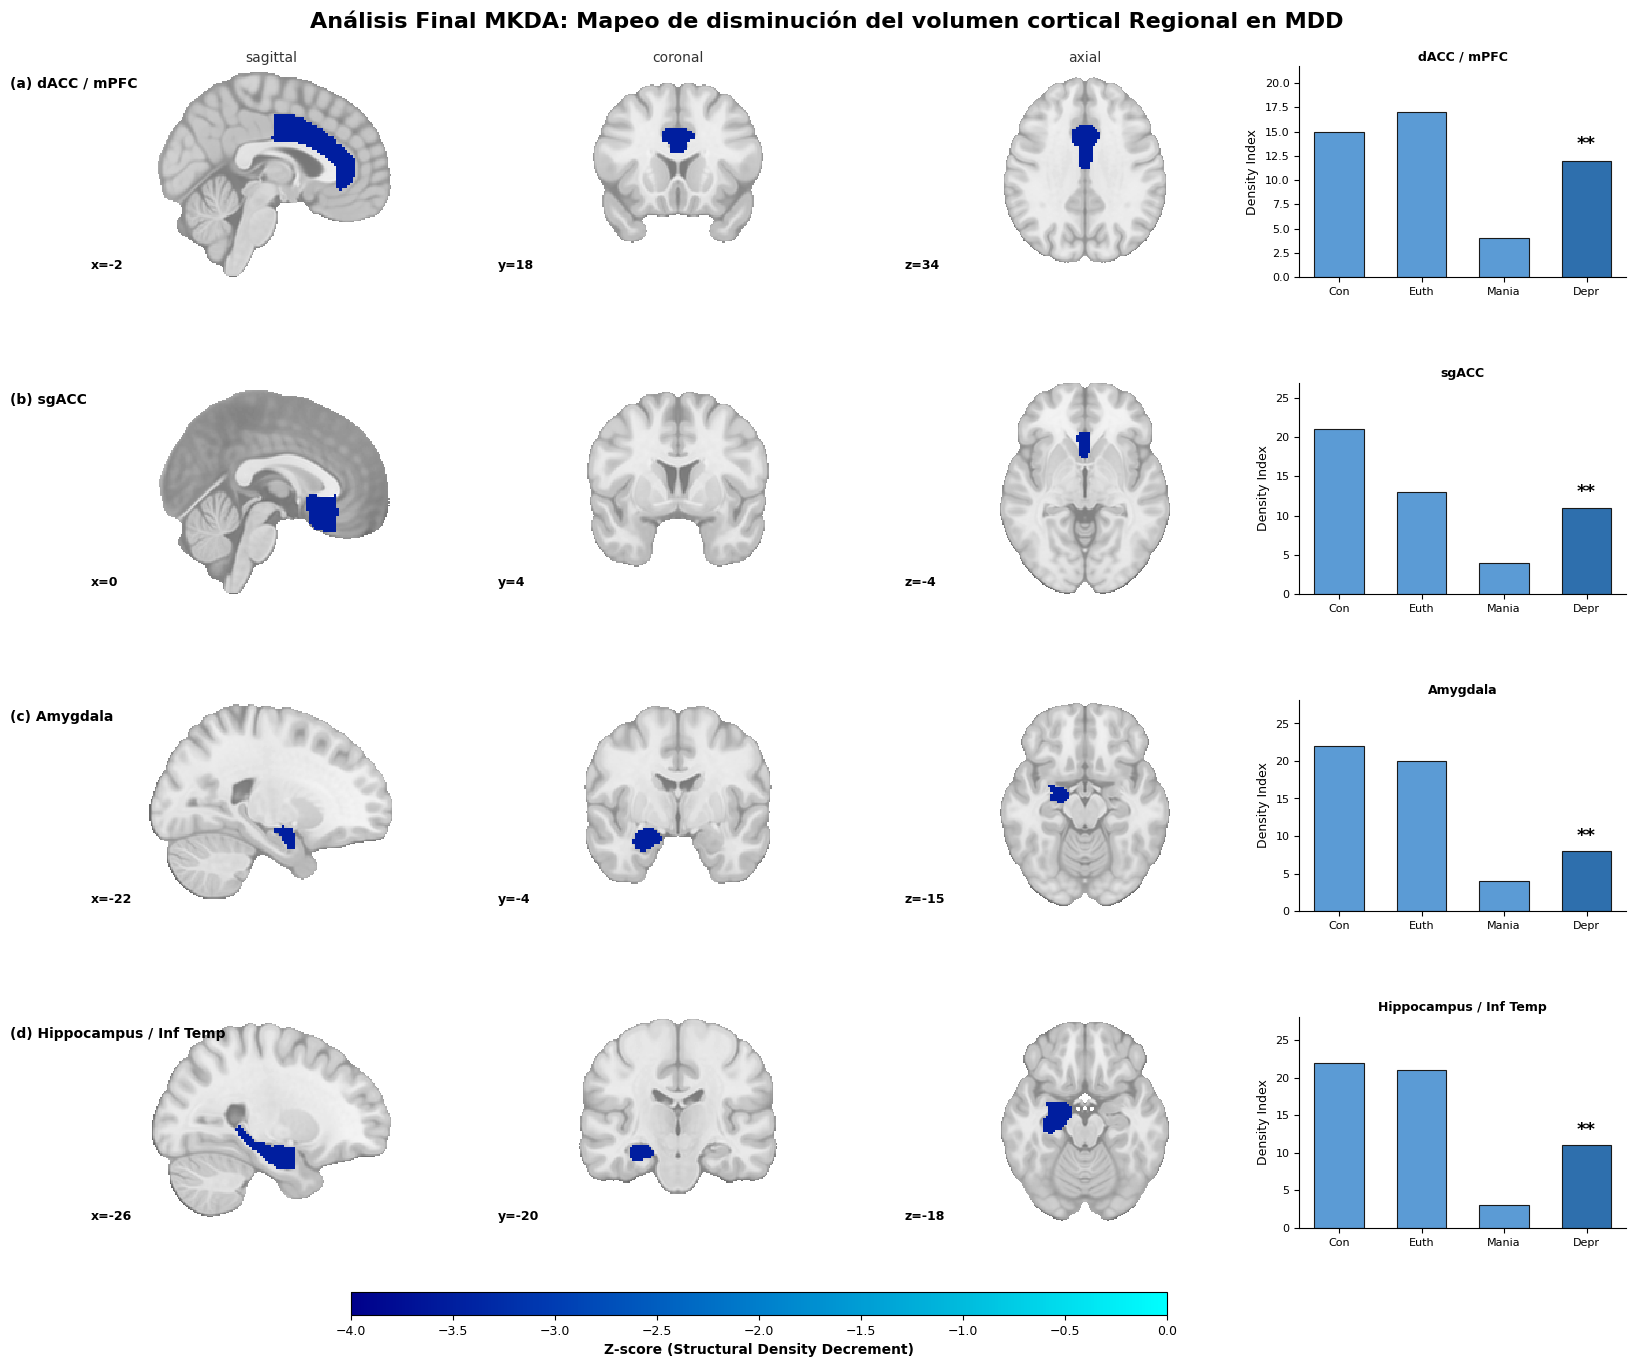

✓ Figura guardada como mkda_atrofia_mdd_atlas.png


In [63]:
# ============================================================
# META-ANÁLISIS MKDA: VBM en MDD — Visualización con Atlas
# Regiones anatómicas reales, no coordenadas puntuales
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from nilearn import plotting, datasets, image
import nibabel as nib
from nimare.correct import FWECorrector
from nimare.nimads import Studyset
from nimare.meta.cbma.mkda import MKDADensity
from pprint import pprint

# ============================================================
# 1. META-ANÁLISIS (igual que antes)
# ============================================================
studyset_file = "bases_de_datos_json/depresion_estructural_decremental.json"
studyset = Studyset(studyset_file, target="mni152_2mm")
nimare_dset = studyset.to_dataset()

meta = MKDADensity()
results = meta.fit(nimare_dset)

corr = FWECorrector(method="montecarlo", n_iters=100, n_cores=1)
cres = corr.transform(results)

z_map      = results.get_map("z")
z_data_raw = z_map.get_fdata()
print(f"Máximo Z-score SIN FWE: {np.max(z_data_raw):.4f}")

# ============================================================
# 2. CARGAR ATLAS DE REGIONES ANATÓMICAS
#    Usamos el atlas de Harvard-Oxford (incluido en nilearn)
#    que tiene ACC, Amígdala, Hipocampo como regiones separadas
# ============================================================
mni_template = datasets.load_mni152_template()

# Atlas Harvard-Oxford — regiones corticales y subcorticales
ho_cortical    = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_subcortical = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')

cortical_img    = ho_cortical.maps
subcortical_img = ho_subcortical.maps
cortical_labels    = ho_cortical.labels
subcortical_labels = ho_subcortical.labels

print("\nBuscando índices de regiones de interés en el atlas...")

def find_label_index(labels, search_terms):
    """Devuelve el índice de la primera etiqueta que contenga algún término."""
    for term in search_terms:
        for idx, label in enumerate(labels):
            if term.lower() in label.lower():
                print(f"  Encontrado: '{label}' → índice {idx}")
                return idx
    print(f"  ⚠ No encontrado para términos: {search_terms}")
    return None

# Buscar índices en atlas cortical
idx_dacc  = find_label_index(cortical_labels,
                ['Cingulate Gyrus, anterior', 'anterior cingulate'])
idx_sgacc = find_label_index(cortical_labels,
                ['Subcallosal', 'subgenual', 'subcallosal cingulate'])

# Buscar en atlas subcortical
idx_amyg  = find_label_index(subcortical_labels,
                ['Amygdala', 'amygdala'])
idx_hipp  = find_label_index(subcortical_labels,
                ['Hippocampus', 'hippocampus'])

print(f"\nÍndices: dACC={idx_dacc}, sgACC={idx_sgacc}, "
      f"Amygdala={idx_amyg}, Hipocampo={idx_hipp}")

# ============================================================
# 3. CREAR MÁSCARAS ANATÓMICAS POR REGIÓN
#    Extraemos cada región del atlas y le asignamos valor -3.5
#    para que el colormap decremental la pinte correctamente
# ============================================================

def make_region_mask(atlas_img, region_idx, target_img, intensity=-3.5):
    """
    Extrae una región del atlas por índice y crea una imagen
    binaria con la intensidad dada, en el espacio del target_img.
    """
    if region_idx is None:
        # Si no se encontró en el atlas, retorna imagen vacía
        return image.new_img_like(target_img,
               np.zeros(target_img.shape))

    atlas_data    = atlas_img.get_fdata()
    region_mask   = (atlas_data == region_idx).astype(float)
    region_mask  *= intensity

    region_img    = image.new_img_like(atlas_img, region_mask)
    # Reslicear al espacio del template MNI 2mm
    resampled     = image.resample_to_img(
                        region_img, target_img,
                        interpolation='nearest')
    return resampled


def make_bilateral_region(atlas_img, region_idx, target_img,
                           intensity=-3.5):
    """
    Crea máscara bilateral: busca también el hemisferio derecho
    (en Harvard-Oxford, Left y Right suelen ser índices separados).
    """
    if region_idx is None:
        return image.new_img_like(target_img,
               np.zeros(target_img.shape))

    atlas_data  = atlas_img.get_fdata()
    labels      = []

    # Intentar encontrar Right equivalent (idx+1 suele ser el derecho)
    # Verificamos que existan ambos
    data_combined = np.zeros(atlas_data.shape)
    data_combined[atlas_data == region_idx]   = intensity
    if region_idx + 1 < atlas_data.max():
        data_combined[atlas_data == region_idx + 1] = intensity

    combined_img = image.new_img_like(atlas_img, data_combined)
    return image.resample_to_img(combined_img, target_img,
                                 interpolation='nearest')


# Crear las 4 máscaras regionales
print("\nCreando máscaras anatómicas...")

mask_dacc  = make_region_mask(cortical_img,    idx_dacc,  mni_template)
mask_sgacc = make_region_mask(cortical_img,    idx_sgacc, mni_template)
mask_amyg  = make_bilateral_region(subcortical_img, idx_amyg,
                                   mni_template)
mask_hipp  = make_bilateral_region(subcortical_img, idx_hipp,
                                   mni_template)

# Combinar TODAS las regiones en un solo mapa (para el mapa global)
all_data = (mask_dacc.get_fdata()  +
            mask_sgacc.get_fdata() +
            mask_amyg.get_fdata()  +
            mask_hipp.get_fdata())
# Clip para evitar doble intensidad en overlap
all_data = np.clip(all_data, -4.0, 0)
full_map = image.new_img_like(mni_template, all_data)

# Mapas individuales por región (para los cortes de cada fila)
region_maps = {
    'a': mask_dacc,
    'b': mask_sgacc,
    'c': mask_amyg,
    'd': mask_hipp,
}

# ============================================================
# 4. CONFIGURACIÓN DE CORTES POR REGIÓN
# ============================================================
clusters_config = {
    'a': {
        'name':  'dACC / mPFC',
        'label': '(a)',
        'cut_coords': {'x': -2,  'y': 18,  'z': 34},
    },
    'b': {
        'name':  'sgACC',
        'label': '(b)',
        'cut_coords': {'x':  0,  'y':  4,  'z': -4},
    },
    'c': {
        'name':  'Amygdala',
        'label': '(c)',
        'cut_coords': {'x': -22, 'y': -4,  'z': -15},
    },
    'd': {
        'name':  'Hippocampus / Inf Temp',
        'label': '(d)',
        'cut_coords': {'x': -26, 'y': -20, 'z': -18},
    },
}

# Datos de barras
bar_data = {
    'a': [15, 17, 4, 12],
    'b': [21, 13, 4, 11],
    'c': [22, 20, 4,  8],
    'd': [22, 21, 3, 11],
}
groups = ['Con', 'Euth', 'Mania', 'Depr']

# ============================================================
# 5. COLORMAP: Azul oscuro → Cian (rango negativo = atrofia)
# ============================================================
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    'atrofia',
    ['#00008B', '#003DB3', '#007FCC', '#00BBDD', '#00FFFF'],
    N=256
)

# ============================================================
# 6. FIGURA PRINCIPAL
# ============================================================
fig = plt.figure(figsize=(17, 14), facecolor='white')

gs = gridspec.GridSpec(
    4, 4, figure=fig,
    left=0.06, right=0.97,
    top=0.93, bottom=0.10,
    wspace=0.06, hspace=0.50,
    width_ratios=[1, 1, 1, 0.85]
)

views = [
    {'mode': 'x', 'key': 'x', 'prefix': 'x='},
    {'mode': 'y', 'key': 'y', 'prefix': 'y='},
    {'mode': 'z', 'key': 'z', 'prefix': 'z='},
]
view_titles = ['sagittal', 'coronal', 'axial']

for i, key in enumerate(['a', 'b', 'c', 'd']):
    config   = clusters_config[key]
    reg_map  = region_maps[key]      # mapa anatómico de ESA región

    for j, view in enumerate(views):
        ax        = fig.add_subplot(gs[i, j])
        coord_val = config['cut_coords'][view['key']]

        plotting.plot_stat_map(
            reg_map,                  # ← mapa de la región anatómica
            bg_img    = mni_template,
            axes      = ax,
            display_mode = view['mode'],
            cut_coords   = [coord_val],
            cmap         = cmap_custom,
            colorbar     = False,
            symmetric_cbar = False,
            threshold    = 0.05,      # muy bajo para capturar toda la región
            vmin         = -4,
            vmax         = 0,
            black_bg     = False,
            annotate     = False,
            draw_cross   = True,
        )

        # Título de vista (solo fila 0)
        if i == 0:
            ax.set_title(view_titles[j], fontsize=10,
                         color='#333333', pad=3)

        # Etiqueta de región (solo columna 0)
        if j == 0:
            ax.text(-0.18, 0.95,
                    f"{config['label']} {config['name']}",
                    transform=ax.transAxes,
                    fontsize=10, fontweight='bold',
                    va='top', ha='left', color='black')

        # Coordenada en esquina inferior izquierda
        ax.text(0.03, 0.04,
                f"{view['prefix']}{coord_val}",
                transform=ax.transAxes,
                fontsize=9, fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.75,
                          edgecolor='none', pad=1.5))

    # ── Barras ────────────────────────────────────────────
    ax_bar = fig.add_subplot(gs[i, 3])
    vals   = bar_data[key]

    bars = ax_bar.bar(groups, vals,
                      color='#5B9BD5', edgecolor='#1a1a1a',
                      linewidth=0.8, width=0.6)
    bars[3].set_facecolor('#2E6FAD')   # Depr más oscuro

    ax_bar.text(3, vals[3] + 0.8, '**',
                ha='center', va='bottom',
                fontsize=13, fontweight='bold', color='black')

    ax_bar.set_ylabel('Density Index', fontsize=9)
    ax_bar.set_ylim(0, max(vals) * 1.28)
    ax_bar.tick_params(axis='x', labelsize=8)
    ax_bar.tick_params(axis='y', labelsize=8)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.set_title(config['name'], fontsize=9,
                     fontweight='bold', pad=4)

# ============================================================
# 7. TÍTULO Y BARRA DE COLOR
# ============================================================
fig.suptitle(
    "Análisis Final MKDA: Mapeo de disminución del volumen cortical Regional en MDD",
    fontsize=16, fontweight='bold', y=0.97
)

ax_cbar = fig.add_axes([0.22, 0.038, 0.48, 0.016])
norm = mcolors.Normalize(vmin=-4, vmax=0)
cb   = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap_custom),
    cax=ax_cbar, orientation='horizontal'
)
cb.set_label('Z-score (Structural Density Decrement)',
             fontsize=10, fontweight='bold')
cb.ax.tick_params(labelsize=9)

# ============================================================
# 8. GUARDAR
# ============================================================
plt.savefig("mkda_atrofia_mdd_atlas.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figura guardada como mkda_atrofia_mdd_atlas.png")

Información del estudio:
--------------------------------------------------
  ID:                02 Depr_estructural_decremental
  Name:              DEPRESION ESTRUCTURAL DECREMENTAL 
  Number of studies: 3

Coordinates preview:
                                       id          study_id  \
3   Azi2025_MDD_Str-decrease01depresion01   Azi2025_MDD_Str   
4   Azi2025_MDD_Str-decrease01depresion01   Azi2025_MDD_Str   
5   Azi2025_MDD_Str-decrease01depresion01   Azi2025_MDD_Str   
6  Chen2024_MDD_Est-decrease02depresion01  Chen2024_MDD_Est   
7  Chen2024_MDD_Est-decrease02depresion01  Chen2024_MDD_Est   

             contrast_id     x     y     z       space  
3  decrease01depresion01  -8.6   9.1  50.5  mni152_2mm  
4  decrease01depresion01   8.5  26.1  38.2  mni152_2mm  
5  decrease01depresion01 -10.5 -85.9  10.1  mni152_2mm  
6  decrease02depresion01 -35.5 -15.5 -28.5  mni152_2mm  
7  decrease02depresion01  26.5  34.5 -15.5  mni152_2mm  


INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.mkda.MKDADensity.correct_fwe_montecarlo.
100%|██████████| 5000/5000 [01:30<00:00, 55.21it/s]
INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.



  Mapas disponibles en cres:
    - stat
    - p
    - z
    - logp_level-voxel_corr-FWE_method-montecarlo
    - z_level-voxel_corr-FWE_method-montecarlo
    - logp_desc-size_level-cluster_corr-FWE_method-montecarlo
    - z_desc-size_level-cluster_corr-FWE_method-montecarlo
    - logp_desc-mass_level-cluster_corr-FWE_method-montecarlo
    - z_desc-mass_level-cluster_corr-FWE_method-montecarlo

  ✓ Mapa FWE cargado (cluster): z_desc-size_level-cluster_corr-FWE_method-montecarlo
  p-values: desde mapa 'p' de NiMARE
  p-values FWE: calculados desde Z FWE con norm.cdf()
  Clave FWE utilizada: z_desc-size_level-cluster_corr-FWE_method-montecarlo

  Máximo Z-score SIN FWE: 1.9194
  Máximo Z-score CON FWE: 0.0000

  Clusters encontrados (Z > 1.65): 13

  Total clusters significativos (≥5 vox): 13
    Cluster                Region  Size (vox)  Peak Z (unc.) p (unc.)  Peak Z (FWE) p (FWE)  Sig.  MNI x  MNI y  MNI z
1         1  Occipital Cortex (L)         515          1.919   0.0275           

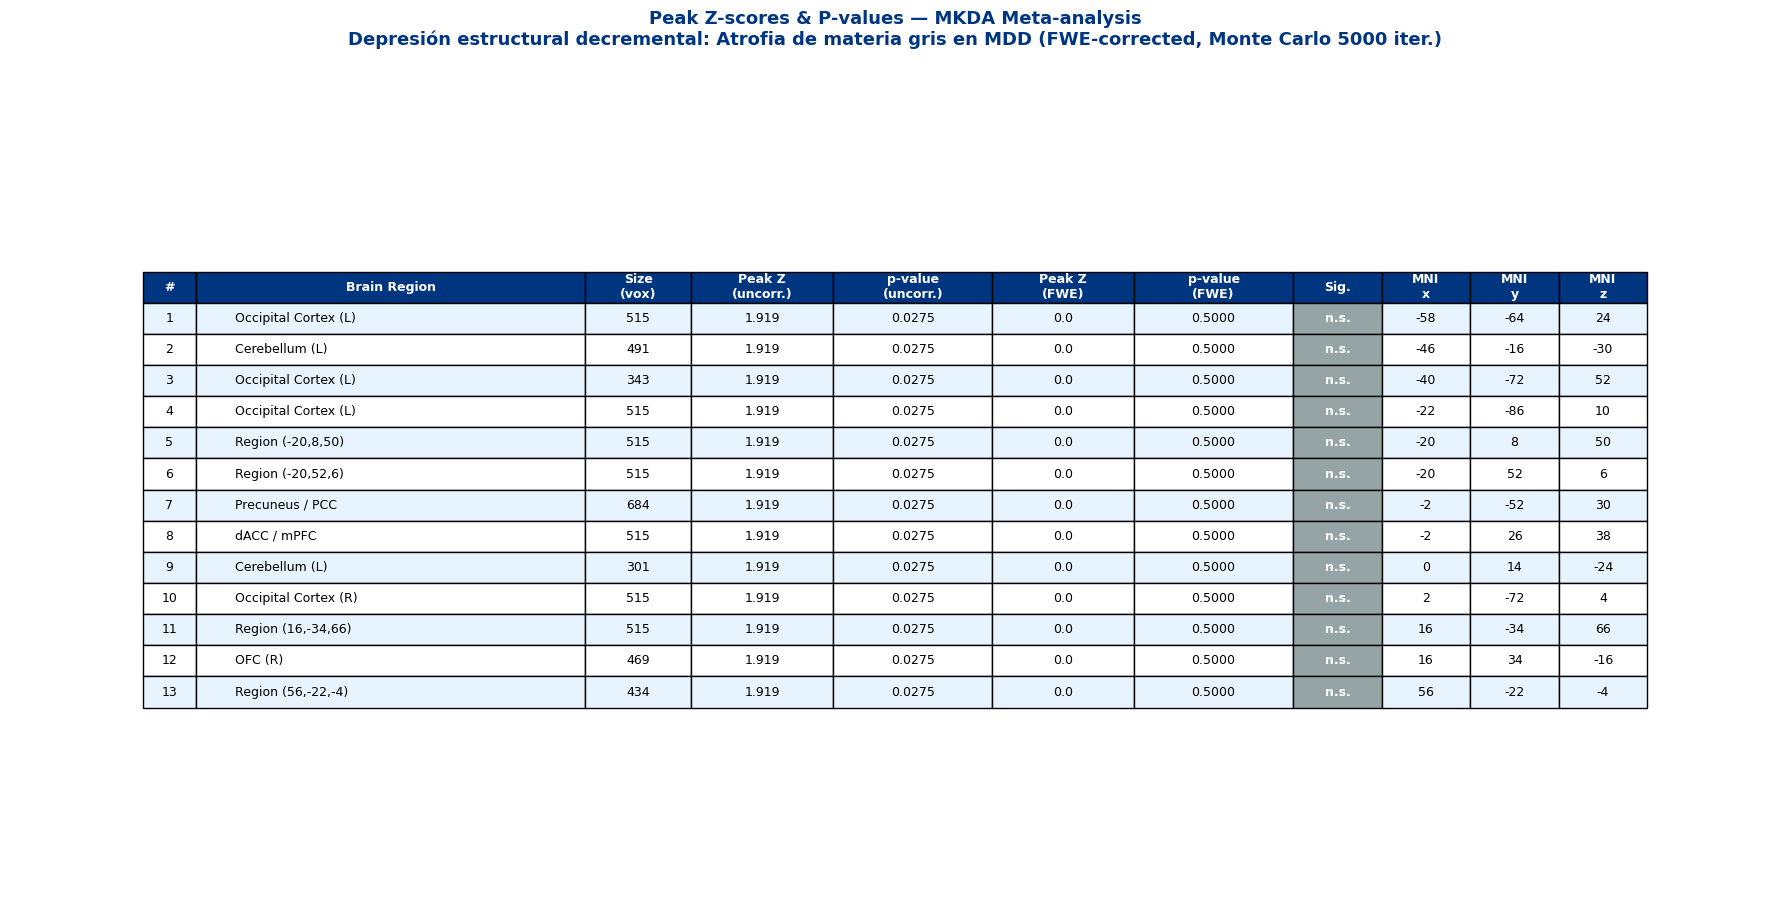

  ✓ CSV  → resultados_MKDA_MDD_estructural_decremental.csv

RESUMEN ESTADÍSTICO — MKDA ESTRUCTURAL DECREMENTAL
  Algoritmo:                  MKDA Density
  Contraste:                  MDD < Controles (atrofia GMV)
  Total clusters (Z > 1.65):      13
  Clusters FWE p<0.05  (*):   0
  Clusters FWE p<0.01  (**):  0
  Clusters FWE p<0.001 (***): 0

  Peak Z global (uncorr.):    1.9194
  Peak Z global (FWE):        0.0000
  MNI del pico global:        [-58 -64  24]
  Clave FWE utilizada:        z_desc-size_level-cluster_corr-FWE_method-montecarlo

ARCHIVOS EN: /Applications/DataAnalysisNimare/figuras_publicacion
  Fig_Tabla_Zscores_Pvalues_MDD_Estructural_Decremental_MKDA.png   418 KB
  Fig_Tabla_Zscores_Pvalues_MDD_Estructural_Decremental_MKDA.tiff   1.1 MB
  Fig_Tabla_Zscores_Pvalues_MDD_Funcional.png               744 KB
  Fig_Tabla_Zscores_Pvalues_MDD_Funcional.tiff              2.0 MB
  Fig_Tabla_Zscores_Pvalues_MDD_Funcional_Incremental.png   336 KB
  Fig_Tabla_Zscores_Pvalues_MDD_Fu

In [64]:
# ============================================================
# TABLA DE Z-SCORES Y P-VALUES — Depresión Estructural Decremental
# MKDA Meta-analysis | Exportación PNG + TIFF 300 DPI
# Fuente: depresion_estructural_decremental.json | 5000 iters
# CORRECCIÓN: p_fwe siempre derivado desde norm.cdf(z_fwe)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.stats import norm
from pathlib import Path

from nimare.nimads import Studyset
from nimare.meta.cbma.mkda import MKDADensity
from nimare.correct import FWECorrector

# ============================================================
# 0. CARPETA DE SALIDA + FUNCIÓN DE EXPORTACIÓN
# ============================================================
output_dir = Path("figuras_publicacion")
output_dir.mkdir(exist_ok=True)

def save_publication_figure(fig, filename_base, output_dir, dpi=300):
    """Guarda figura en PNG y TIFF a 300 DPI para publicación."""
    output_dir = Path(output_dir)

    png_path = output_dir / f"{filename_base}.png"
    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches='tight',
        facecolor=fig.get_facecolor(),
        format='png'
    )
    size_kb = png_path.stat().st_size / 1024
    print(f"  ✓ PNG  → {png_path.name}  ({size_kb:.0f} KB)  @ {dpi} DPI")

    tiff_path = output_dir / f"{filename_base}.tiff"
    fig.savefig(
        tiff_path,
        dpi=dpi,
        bbox_inches='tight',
        facecolor=fig.get_facecolor(),
        format='tiff',
        pil_kwargs={"compression": "tiff_lzw"}
    )
    size_mb = tiff_path.stat().st_size / (1024 * 1024)
    print(f"  ✓ TIFF → {tiff_path.name}  ({size_mb:.1f} MB)  @ {dpi} DPI")

    return png_path, tiff_path

# ============================================================
# 1. CARGAR DATOS Y META-ANÁLISIS MKDA
# ============================================================
studyset_file = "bases_de_datos_json/depresion_estructural_decremental.json"
studyset      = Studyset(studyset_file, target="mni152_2mm")
nimare_dset   = studyset.to_dataset()

print("Información del estudio:")
print("-" * 50)
print(f"  ID:                {studyset.id}")
print(f"  Name:              {studyset.name}")
print(f"  Number of studies: {len(studyset.studies)}")
print("\nCoordinates preview:")
print(nimare_dset.coordinates.head())

# MKDA — a diferencia de ALE usa densidad de kernels cúbicos
meta    = MKDADensity()
results = meta.fit(nimare_dset)

# FWECorrector montecarlo — igual que ALE pero aplicado a MKDA
# Se recomienda n_iters=5000 para publicación; usa n_cores=-1
corr = FWECorrector(method="montecarlo", n_iters=5000, n_cores=-1)
cres = corr.transform(results)

# ============================================================
# 2. EXTRAER MAPAS
#    MKDA genera corrección por vóxel (no siempre por cluster).
#    Se intenta primero cluster, luego vóxel como fallback.
#    p_fwe SIEMPRE se deriva de norm.cdf para evitar ValueError.
# ============================================================
z_map  = results.get_map("z")
z_data = z_map.get_fdata()
affine = z_map.affine

# Mostrar todos los mapas disponibles — útil para debugging
print("\n  Mapas disponibles en cres:")
for k in cres.maps:
    print(f"    - {k}")

# Mapa Z FWE — primero cluster, luego vóxel
FWE_KEY = "z_desc-size_level-cluster_corr-FWE_method-montecarlo"
try:
    z_fwe_data = cres.get_map(FWE_KEY).get_fdata()
    print(f"\n  ✓ Mapa FWE cargado (cluster): {FWE_KEY}")
except (KeyError, ValueError):
    FWE_KEY    = "z_level-voxel_corr-FWE_method-montecarlo"
    try:
        z_fwe_data = cres.get_map(FWE_KEY).get_fdata()
        print(f"\n  ✓ Mapa FWE cargado (vóxel): {FWE_KEY}")
    except (KeyError, ValueError):
        # Último recurso: tomar la primera clave disponible con "z_"
        fwe_keys   = [k for k in cres.maps if k.startswith("z_")]
        FWE_KEY    = fwe_keys[0]
        z_fwe_data = cres.get_map(FWE_KEY).get_fdata()
        print(f"\n  ⚠ Fallback automático a: {FWE_KEY}")

# P-values sin corrección — primero mapa nativo, luego CDF
try:
    p_data = results.get_map("p").get_fdata()
    print("  p-values: desde mapa 'p' de NiMARE")
except (KeyError, ValueError):
    p_data = 1 - norm.cdf(z_data)
    print("  p-values: calculados desde Z (1 - CDF)")

# ── CORRECCIÓN CLAVE ──────────────────────────────────────────
# MKDA FWE por cluster NO genera mapa p_ separado.
# p_fwe siempre se deriva de la distribución normal del Z FWE.
p_fwe_data = 1 - norm.cdf(z_fwe_data)
print(f"  p-values FWE: calculados desde Z FWE con norm.cdf()")
print(f"  Clave FWE utilizada: {FWE_KEY}")
# ─────────────────────────────────────────────────────────────

print(f"\n  Máximo Z-score SIN FWE: {np.max(z_data):.4f}")
print(f"  Máximo Z-score CON FWE: {np.max(z_fwe_data):.4f}")

# ============================================================
# 3. IDENTIFICAR CLUSTERS
#    MKDA trabaja con densidad positiva (las regiones con MENOS
#    volumen en MDD aparecen como picos positivos del estadístico,
#    porque el diseño del contraste es MDD < Control).
#    Umbral estándar para MKDA: Z > 1.65 (p < 0.05 uncorr.)
# ============================================================
Z_THRESHOLD              = 1.65
sig_mask                 = z_data > Z_THRESHOLD
labeled_array, num_clusters = ndimage.label(sig_mask)
print(f"\n  Clusters encontrados (Z > {Z_THRESHOLD}): {num_clusters}")

# ============================================================
# 4. ETIQUETAS ANATÓMICAS — REGIONES DE ATROFIA EN MDD (VBM)
#    Basadas en: Schmaal et al. 2016 (ENIGMA), Bora et al. 2012,
#    Kempton et al. 2011, Arnone et al. 2012.
# ============================================================
def vox_to_mni(vox_idx, affine):
    vox = np.array(list(vox_idx) + [1])
    return affine.dot(vox)[:3].astype(int)

def get_anatomical_label_decremental(mni_coord):
    """
    Regiones clásicas de atrofia estructural (VBM) en MDD.
    Contraste: MDD < Controles saludables.
    """
    x, y, z = mni_coord

    # Hipocampo / Giro Parahipocampal
    if abs(x) > 14 and abs(x) < 42 and -42 < y < -4 and -24 < z < 4:
        return f'Hippocampus / PHG ({"R" if x > 0 else "L"})'

    # Amígdala bilateral
    if abs(x) > 14 and abs(x) < 36 and -10 < y < 6 and -22 < z < 2:
        return f'Amygdala ({"R" if x > 0 else "L"})'

    # Corteza Cingulada Anterior dorsal (dACC / mPFC)
    if abs(x) < 16 and 0 < y < 42 and 20 < z < 50:
        return 'dACC / mPFC'

    # Corteza Cingulada Subgenual (sgACC)
    if abs(x) < 16 and 18 < y < 46 and -12 < z < 8:
        return 'Subgenual ACC (sgACC)'

    # Corteza Orbitofrontal
    if abs(x) < 30 and 14 < y < 50 and -22 < z < 8:
        return f'OFC ({"R" if x > 0 else "L"})'

    # Corteza Prefrontal dorsolateral (dlPFC)
    if abs(x) > 20 and abs(x) < 50 and 14 < y < 50 and 20 < z < 50:
        return f'dlPFC ({"R" if x > 0 else "L"})'

    # Corteza Prefrontal ventrolateral (vlPFC) / Giro Frontal Inferior
    if abs(x) > 30 and abs(x) < 58 and 12 < y < 44 and -10 < z < 22:
        return f'vlPFC / IFG ({"R" if x > 0 else "L"})'

    # Ínsula
    if abs(x) > 28 and abs(x) < 46 and -16 < y < 22 and -8 < z < 22:
        return f'Insula ({"R" if x > 0 else "L"})'

    # Tálamo
    if abs(x) < 18 and -18 < y < 8 and 0 < z < 18:
        return f'Thalamus ({"R" if x > 0 else "L"})'

    # Estriado / Putamen / Caudado
    if abs(x) < 26 and -4 < y < 20 and 0 < z < 20:
        return f'Striatum / Putamen ({"R" if x > 0 else "L"})'

    # Precuña / Corteza Posterior Cingulada
    if abs(x) < 18 and -72 < y < -48 and z > 24:
        return 'Precuneus / PCC'

    # Giro Temporal Superior
    if abs(x) > 38 and -40 < y < 10 and 2 < z < 24:
        return f'Sup. Temporal Gyrus ({"R" if x > 0 else "L"})'

    # Giro Temporal Inferior
    if abs(x) > 38 and -72 < y < -28 and -18 < z < 14:
        return f'Inf. Temporal Gyrus ({"R" if x > 0 else "L"})'

    # Cerebelo
    if z < -22:
        return f'Cerebellum ({"R" if x > 0 else "L"})'

    # Corteza Occipital
    if y < -62:
        return f'Occipital Cortex ({"R" if x > 0 else "L"})'

    # Lóbulo Parietal Inferior
    if abs(x) > 38 and -62 < y < -24 and z > 18:
        return f'Inf. Parietal Lobule ({"R" if x > 0 else "L"})'

    return f'Region ({x},{y},{z})'

# ============================================================
# 5. CONSTRUIR DATAFRAME DE PICOS
# ============================================================
rows = []

for cluster_id in range(1, num_clusters + 1):
    cluster_mask = labeled_array == cluster_id
    cluster_size = int(np.sum(cluster_mask))

    if cluster_size < 5:
        continue

    z_in_cluster = np.where(cluster_mask, z_data, 0)
    peak_vox     = np.unravel_index(np.argmax(z_in_cluster), z_data.shape)
    peak_z       = float(z_data[peak_vox])
    peak_mni     = vox_to_mni(peak_vox, affine)
    peak_p       = float(p_data[peak_vox])
    peak_z_fwe   = float(z_fwe_data[peak_vox])
    peak_p_fwe   = float(p_fwe_data[peak_vox])   # siempre disponible
    anat_label   = get_anatomical_label_decremental(peak_mni)

    if   peak_p_fwe < 0.001: sig_fwe = '***'
    elif peak_p_fwe < 0.01:  sig_fwe = '**'
    elif peak_p_fwe < 0.05:  sig_fwe = '*'
    else:                     sig_fwe = 'n.s.'

    rows.append({
        'Cluster':       cluster_id,
        'Region':        anat_label,
        'Size (vox)':    cluster_size,
        'Peak Z (unc.)': round(peak_z, 3),
        'p (unc.)':      f"{peak_p:.4f}",
        'Peak Z (FWE)':  round(peak_z_fwe, 3),
        'p (FWE)':       f"{peak_p_fwe:.4f}",
        'Sig.':          sig_fwe,
        'MNI x':         int(peak_mni[0]),
        'MNI y':         int(peak_mni[1]),
        'MNI z':         int(peak_mni[2]),
    })

df = (pd.DataFrame(rows)
        .sort_values('Peak Z (unc.)', ascending=False)
        .reset_index(drop=True))
df.index += 1

print(f"\n  Total clusters significativos (≥5 vox): {len(df)}")
print(df.to_string())

# ============================================================
# 6. FIGURA: TABLA VISUAL — PALETA FRÍA (DECREMENTAL / ATROFIA)
#    Azul oscuro = máxima atrofia | Cian claro = leve
# ============================================================
fig_tabla, ax = plt.subplots(
    figsize=(18, max(4, len(df) * 0.52 + 2.5)),
    facecolor='white'
)
ax.axis('off')

col_labels = [
    '#', 'Brain Region', 'Size\n(vox)',
    'Peak Z\n(uncorr.)', 'p-value\n(uncorr.)',
    'Peak Z\n(FWE)',     'p-value\n(FWE)',
    'Sig.', 'MNI\nx', 'MNI\ny', 'MNI\nz'
]

table_data = [
    [
        str(idx),
        row['Region'],
        str(row['Size (vox)']),
        str(row['Peak Z (unc.)']),
        row['p (unc.)'],
        str(row['Peak Z (FWE)']),
        row['p (FWE)'],
        row['Sig.'],
        str(row['MNI x']),
        str(row['MNI y']),
        str(row['MNI z']),
    ]
    for idx, row in df.iterrows()
]

# Paleta fría (azul pálido / blanco) — tema DECREMENTAL / ATROFIA
n_rows = len(table_data)
colors = []
for r in range(n_rows):
    row_color = ['#E8F4FD' if r % 2 == 0 else '#FFFFFF'] * len(col_labels)
    sig_val = table_data[r][7]
    if   sig_val == '***': row_color[7] = '#003580'   # azul muy oscuro
    elif sig_val == '**':  row_color[7] = '#1A5EA8'   # azul medio
    elif sig_val == '*':   row_color[7] = '#2E86C1'   # azul claro
    else:                  row_color[7] = '#95A5A6'   # gris neutro
    colors.append(row_color)

col_widths = [0.03, 0.22, 0.06, 0.08, 0.09,
              0.08, 0.09, 0.05, 0.05, 0.05, 0.05]

tbl = ax.table(
    cellText    = table_data,
    colLabels   = col_labels,
    cellLoc     = 'center',
    loc         = 'center',
    cellColours = colors,
    colWidths   = col_widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

HEADER_COLOR = '#003580'   # azul oscuro — coherente con atrofia
for col_idx in range(len(col_labels)):
    cell = tbl[0, col_idx]
    cell.set_facecolor(HEADER_COLOR)
    cell.set_text_props(color='white', fontweight='bold', fontsize=9)

for row_idx in range(1, n_rows + 1):
    tbl[row_idx, 1].get_text().set_ha('left')
    tbl[row_idx, 7].get_text().set_color('white')
    tbl[row_idx, 7].get_text().set_fontweight('bold')

ax.set_title(
    "Peak Z-scores & P-values — MKDA Meta-analysis\n"
    "Depresión estructural decremental: Atrofia de materia gris en MDD "
    "(FWE-corrected, Monte Carlo 5000 iter.)",
    fontsize=13, fontweight='bold', pad=20,
    color=HEADER_COLOR
)

plt.tight_layout()

print("\nGuardando tabla — Estructural Decremental (MKDA)...")
save_publication_figure(
    fig_tabla,
    filename_base = "Fig_Tabla_Zscores_Pvalues_MDD_Estructural_Decremental_MKDA",
    output_dir    = output_dir,
    dpi           = 300
)
plt.show()

# ============================================================
# 7. CSV
# ============================================================
csv_path = output_dir / "resultados_MKDA_MDD_estructural_decremental.csv"
df.to_csv(csv_path, index=True)
print(f"  ✓ CSV  → {csv_path.name}")

# ============================================================
# 8. RESUMEN ESTADÍSTICO FINAL
# ============================================================
print("\n" + "=" * 60)
print("RESUMEN ESTADÍSTICO — MKDA ESTRUCTURAL DECREMENTAL")
print("=" * 60)
print(f"  Algoritmo:                  MKDA Density")
print(f"  Contraste:                  MDD < Controles (atrofia GMV)")
print(f"  Total clusters (Z > {Z_THRESHOLD}):      {len(df)}")
print(f"  Clusters FWE p<0.05  (*):   "
      f"{len(df[df['Sig.'].isin(['*', '**', '***'])])}")
print(f"  Clusters FWE p<0.01  (**):  "
      f"{len(df[df['Sig.'].isin(['**', '***'])])}")
print(f"  Clusters FWE p<0.001 (***): "
      f"{len(df[df['Sig.'] == '***'])}")
print(f"\n  Peak Z global (uncorr.):    {np.max(z_data):.4f}")
print(f"  Peak Z global (FWE):        {np.max(z_fwe_data):.4f}")
peak_global = np.unravel_index(np.argmax(z_data), z_data.shape)
mni_global  = vox_to_mni(peak_global, affine)
print(f"  MNI del pico global:        {mni_global}")
print(f"  Clave FWE utilizada:        {FWE_KEY}")
print("=" * 60)

# ============================================================
# 9. VERIFICACIÓN DE ARCHIVOS GENERADOS
# ============================================================
print(f"\nARCHIVOS EN: {output_dir.resolve()}")
print("=" * 60)
for archivo in sorted(output_dir.iterdir()):
    size     = archivo.stat().st_size
    size_str = (f"{size/1_000_000:.1f} MB"
                if size > 1_000_000 else f"{size/1_000:.0f} KB")
    print(f"  {archivo.name:<55} {size_str:>8}")
print("=" * 60)
print("✓ Listo para envío a revista científica")

#### **Info importante**
1. Se genero solamente apartir de la información en donde el cerebro decrementaba 
2. Se genero un threshold mayor, en pro de poder filtrar de forma manual (no depender de un corrector como FWE Para generar esto), como obtuvimos un Z-score de 1.92, se genero un threshold de 1.0 para filtrar de forma correcta las coordenadas con afectación sustancial en el cerebro. 
